# ST422 Brief 8 — Road Safety Analysis
## Combined Analysis Notebook

**Purpose:** Loads STATS19 data, cleans and merges, performs EDA, trend analysis,
hotspot identification, contributory factor analysis, robustness checks,
uncertainty quantification, and OLS diagnostics.

**Inputs:**
- `Data/` — raw DfT STATS19 CSVs (see README.md for filenames)
- `Cleaned/cas_full.csv` — produced by ST422_DataPrep.ipynb

**Outputs:**
- `outputs/fig_*.png` — all figures saved for traceability
- `outputs/tab_*.csv` — all key tables saved for traceability

**Run order:** Run ST422_DataPrep.ipynb first, then this notebook top to bottom.
Restart kernel before a full re-run to guarantee a clean state.


In [35]:
import geopandas as gpd
print(gpd.__version__)

1.1.3


## 0. Config and Setup

In [29]:
# ── USER CONFIG ───────────────────────────────────────────────────────────────
# No path editing required — all paths are relative to project root.
import os


NOTEBOOK_DIR = os.getcwd()
DATA_DIR     = os.path.join(NOTEBOOK_DIR, 'Data')
CLEANED_DIR  = os.path.join(NOTEBOOK_DIR, 'Cleaned')
OUTPUT_DIR   = os.path.join(NOTEBOOK_DIR, 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Year windows
YEAR_START       = 2014
YEAR_END         = 2024
COVID_YEARS      = [2020, 2021]
BASE_YEARS       = [2015, 2016, 2017]
RECENT_YEARS     = [2022, 2023, 2024]

# OLS thresholds (Week 10)
MIN_KSI_BASE = 30
MIN_YEARS    = 6
LOW_R2       = 0.5
TOP_N        = 5
TOP_N_LINES  = 3

# File paths
COLLISION_HIST = os.path.join(DATA_DIR, 'dft-road-casualty-statistics-collision-1979-latest-published-year.csv')
CASUALTY_HIST  = os.path.join(DATA_DIR, 'dft-road-casualty-statistics-casualty-1979-latest-published-year.csv')
VEHICLE_HIST   = os.path.join(DATA_DIR, 'dft-road-casualty-statistics-vehicle-1979-latest-published-year.csv')
COLLISION_PROV = os.path.join(DATA_DIR, 'dft-road-casualty-statistics-collision-provisional-2025.csv')
CASUALTY_PROV  = os.path.join(DATA_DIR, 'dft-road-casualty-statistics-casualty-provisional-2025.csv')
VEHICLE_PROV   = os.path.join(DATA_DIR, 'dft-road-casualty-statistics-vehicle-provisional-2025.csv')
LA_LOOKUP      = os.path.join(DATA_DIR, 'local-authority-ons-district-names.csv')
CAS_FULL       = os.path.join(CLEANED_DIR, 'cas_full.csv')

print('DATA_DIR   :', DATA_DIR,    '| exists:', os.path.exists(DATA_DIR))
print('CLEANED_DIR:', CLEANED_DIR, '| exists:', os.path.exists(CLEANED_DIR))
print('OUTPUT_DIR :', OUTPUT_DIR,  '| exists:', os.path.exists(OUTPUT_DIR))


ModuleNotFoundError: No module named 'geopandas'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif', 'figure.dpi': 120
})

DTYPE = {'collision_index': str, 'collision_ref_no': str}

def savefig(name):
    """Save current figure to outputs/ folder."""
    path = os.path.join(OUTPUT_DIR, f'{name}.png')
    plt.savefig(path, dpi=120, bbox_inches='tight')
    print(f'Saved: {path}')


---
## 1. Data Load and Preparation

Loads the full STATS19 historical files (2014–2024) and provisional 2025 data.
Invalid codes (-1) replaced with NaN. Derived columns and label maps applied.


In [3]:
# Load historical files
col_hist = pd.read_csv(COLLISION_HIST, dtype=DTYPE, low_memory=False)
cas_hist = pd.read_csv(CASUALTY_HIST,  dtype=DTYPE, low_memory=False)
veh_hist = pd.read_csv(VEHICLE_HIST,   dtype=DTYPE, low_memory=False)
for df in [col_hist, cas_hist, veh_hist]:
    df.columns = df.columns.str.lower()
col_hist = col_hist[col_hist['collision_year'].between(YEAR_START, YEAR_END)].copy()
cas_hist = cas_hist[cas_hist['collision_year'].between(YEAR_START, YEAR_END)].copy()
veh_hist = veh_hist[veh_hist['collision_year'].between(YEAR_START, YEAR_END)].copy()

# Load and append provisional 2025
col_prov = pd.read_csv(COLLISION_PROV, dtype=DTYPE, low_memory=False)
cas_prov = pd.read_csv(CASUALTY_PROV,  dtype=DTYPE, low_memory=False)
veh_prov = pd.read_csv(VEHICLE_PROV,   dtype=DTYPE, low_memory=False)
for df in [col_prov, cas_prov, veh_prov]:
    df.columns = df.columns.str.lower()
    df['provisional'] = True

col = pd.concat([col_hist, col_prov], ignore_index=True)
cas = pd.concat([cas_hist, cas_prov], ignore_index=True)
veh = pd.concat([veh_hist, veh_prov], ignore_index=True)
for df in [col, cas, veh]:
    df['provisional'] = df.get('provisional', False).fillna(False)

YEARS = sorted(col['collision_year'].dropna().unique().astype(int).tolist())
print(f'col: {len(col):,}  cas: {len(cas):,}  veh: {len(veh):,}')
print(f'Years: {YEARS}')


col: 1,345,099  cas: 1,748,311  veh: 2,469,085
Years: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [4]:
# Clean coded fields — replace -1 with NaN
CODED_COL = ['collision_severity','enhanced_severity_collision','speed_limit','road_type',
             'junction_detail','junction_control','light_conditions','urban_or_rural_area',
             'police_force','collision_injury_based','day_of_week','weather_conditions','road_surface_conditions']
CODED_CAS = ['casualty_severity','enhanced_casualty_severity','casualty_type','casualty_class',
             'age_of_casualty','age_band_of_casualty','sex_of_casualty','casualty_imd_decile','casualty_injury_based']
CODED_VEH = ['vehicle_type','sex_of_driver','age_of_driver','age_band_of_driver',
             'journey_purpose_of_driver','driver_imd_decile','propulsion_code']

for fields, df in [(CODED_COL, col), (CODED_CAS, cas), (CODED_VEH, veh)]:
    for f in fields:
        if f in df.columns:
            df[f] = pd.to_numeric(df[f], errors='coerce')
            df.loc[df[f] < 0, f] = np.nan

# Derived columns
col['date']  = pd.to_datetime(col['date'], dayfirst=True, errors='coerce')
col['month'] = col['date'].dt.month
col['ksi']   = col['collision_severity'].isin([1, 2])
col['fatal'] = col['collision_severity'] == 1

# Label maps
GROUPED_MAP  = {1:'Pedestrian',2:'Cyclist',3:'Motorcycle rider',4:'Motorcycle rider',
                5:'Motorcycle rider',23:'Motorcycle rider',97:'Motorcycle rider',
                8:'Taxi/PHV occupant',9:'Car occupant',10:'Minibus/bus occupant',
                11:'Minibus/bus occupant',19:'Van occupant',20:'HGV occupant',21:'HGV occupant',
                16:'Other',17:'Other',18:'Other',22:'Other',90:'Other',98:'Unknown',99:'Unknown'}
URBAN_MAP    = {1:'Urban',2:'Rural',3:'Unallocated'}
ROAD_MAP     = {1:'Roundabout',2:'One way street',3:'Dual carriageway',
                6:'Single carriageway',7:'Slip road',9:'Unknown',12:'One way/Slip road'}
JUNCTION_MAP = {0:'Not at junction',13:'T or Y junction',16:'Crossroads',
                17:'More than 4 arms',18:'Private drive or entrance',19:'Other junction',99:'Unknown'}
DAY_MAP      = {1:'Sun',2:'Mon',3:'Tue',4:'Wed',5:'Thu',6:'Fri',7:'Sat'}
FORCE_MAP    = {1:'Metropolitan Police',3:'Cumbria',4:'Lancashire',5:'Merseyside',
                6:'Greater Manchester',7:'Cheshire',10:'Humberside',11:'West Yorkshire',
                12:'South Yorkshire',13:'West Midlands',14:'East Midlands',16:'Staffordshire',
                17:'West Mercia',20:'Thames Valley',21:'Hampshire',22:'South East',
                23:'Essex',24:'Norfolk',25:'Suffolk',26:'Bedfordshire',27:'Hertfordshire',
                30:'Cambridgeshire',31:'Northamptonshire',32:'Leicestershire',33:'Warwickshire',
                34:'Avon and Somerset',35:'Gloucestershire',36:'Wiltshire',37:'Dorset',
                38:'Devon and Cornwall',39:'Sussex',40:'Kent',41:'Surrey',42:'Northumbria',
                43:'Durham',44:'North Yorkshire',45:'Dyfed-Powys',46:'Gwent',47:'South Wales',
                48:'North Wales',50:'Lincolnshire',52:'Cleveland',53:'City of London',
                54:'Nottinghamshire',55:'Derbyshire',99:'Unknown/Other'}

cas['road_user']       = cas['casualty_type'].map(GROUPED_MAP).fillna('Unknown')
col['ur_label']        = col['urban_or_rural_area'].map(URBAN_MAP)
col['road_type_label'] = col['road_type'].map(ROAD_MAP)
col['junction_label']  = col['junction_detail'].map(JUNCTION_MAP)
col['day_label']       = col['day_of_week'].map(DAY_MAP)
col['force_name']      = col['police_force'].map(FORCE_MAP).fillna('Unknown')

la_lookup = pd.read_csv(LA_LOOKUP)[['code','la_name']].rename(columns={'code':'local_authority_ons_district'})
col = col.merge(la_lookup, on='local_authority_ons_district', how='left')
print('Cleaning and label maps complete.')
print(f'col: {col.shape}  cas: {cas.shape}  veh: {veh.shape}')


Cleaning and label maps complete.
col: (1347870, 54)  cas: (1748311, 25)  veh: (2469085, 33)


---
## 2. Exploratory Analysis and Descriptive Checks

**EDA objectives:** Before any modelling, we check (1) data completeness and
missingness patterns, (2) IBRS adoption — the most important data quality issue
for this analysis, (3) geographic and temporal coverage gaps, (4) coordinate
quality for hotspot mapping, and (5) distributional checks on the primary outcome.
These checks inform which fields can be used reliably and which require caveating.


In [5]:
# 2.1 Missingness summary
NON_NEGATIVE_CHECK = CODED_COL + CODED_CAS + CODED_VEH

def missingness(df, fields):
    rows = []
    for f in fields:
        if f not in df.columns:
            rows.append({'Field': f, 'Missing (n)': '-', 'Missing (%)': '-'})
            continue
        if f in NON_NEGATIVE_CHECK:
            null_mask = df[f].isna() | (pd.to_numeric(df[f], errors='coerce') < 0)
        else:
            null_mask = df[f].isna()
        n   = null_mask.sum()
        pct = n / len(df) * 100
        flag = '  *** HIGH ***' if pct > 5 else ''
        rows.append({'Field': f, 'Missing (n)': f'{n:,}', 'Missing (%)': f'{pct:.1f}%{flag}'})
    return pd.DataFrame(rows)

key_col = ['collision_severity','enhanced_severity_collision','date','latitude','longitude',
           'speed_limit','road_type','junction_detail','light_conditions','urban_or_rural_area',
           'collision_injury_based','collision_adjusted_severity_serious']
print('=== Collision table missingness ===')
display(missingness(col, key_col))


=== Collision table missingness ===


,Field,Missing (n),Missing (%)
0,collision_severity,0,0.0%
1,enhanced_severity_collision,"859,238",63.7% *** HIGH ***
2,date,0,0.0%
3,latitude,203,0.0%
4,longitude,203,0.0%
5,speed_limit,317,0.0%
6,road_type,1,0.0%
7,junction_detail,"23,095",1.7%
8,light_conditions,341,0.0%
9,urban_or_rural_area,9,0.0%


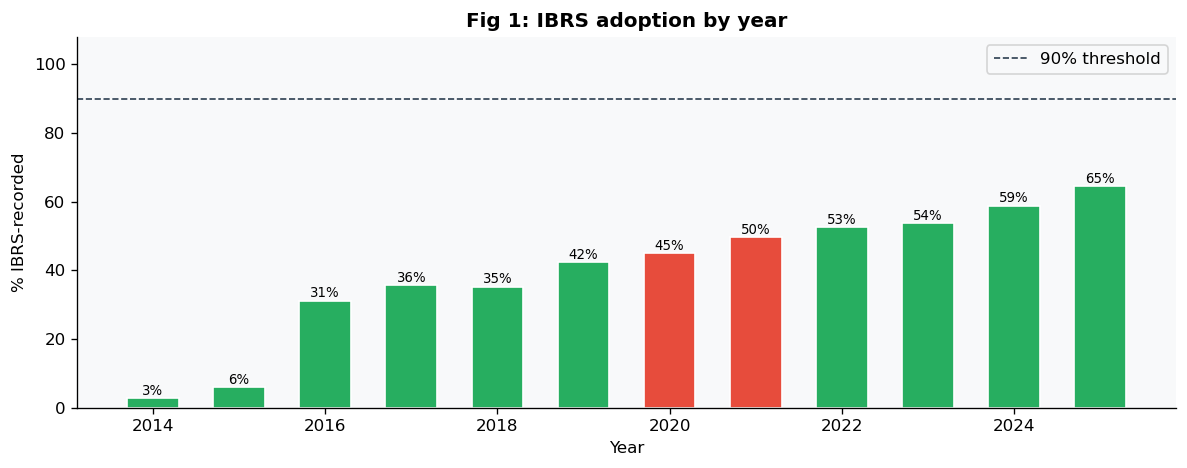

Saved: C:\Users\u2211111\outputs\fig_01_ibrs_adoption.png
 year  ibrs_pct
 2014       2.7
 2015       5.9
 2016      31.2
 2017      35.6
 2018      35.2
 2019      42.3
 2020      45.0
 2021      49.7
 2022      52.6
 2023      53.8
 2024      58.8
 2025      64.6


<Figure size 768x576 with 0 Axes>

In [6]:
# 2.2 IBRS adoption by year
ibrs = (col.groupby('collision_year')['collision_injury_based']
        .apply(lambda x: (x==1).sum()/len(x)*100).reset_index())
ibrs.columns = ['year','ibrs_pct']
ibrs['ibrs_pct'] = ibrs['ibrs_pct'].round(1)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#e74c3c' if y in COVID_YEARS else '#27ae60' for y in ibrs['year']]
bars = ax.bar(ibrs['year'], ibrs['ibrs_pct'], color=colors, width=0.6, edgecolor='white')
ax.axhline(90, color='#2c3e50', linestyle='--', linewidth=1, label='90% threshold')
for bar, val in zip(bars, ibrs['ibrs_pct']):
    ax.text(bar.get_x()+bar.get_width()/2, val+1, f'{val:.0f}%', ha='center', fontsize=8)
ax.set_ylim(0, 108)
ax.set_xlabel('Year'); ax.set_ylabel('% IBRS-recorded')
ax.set_title('Fig 1: IBRS adoption by year', fontweight='bold')
ax.legend()
plt.tight_layout(); savefig('fig_01_ibrs_adoption'); plt.show()
print(ibrs.to_string(index=False))


In [7]:
# 2.3 Severity distribution by year — distributional check
sev = col.groupby(['collision_year','collision_severity']).size().unstack(fill_value=0)
sev = sev.rename(columns={1:'Fatal',2:'Serious',3:'Slight'})
sev['KSI']   = sev['Fatal'] + sev['Serious']
sev['Total'] = sev[['Fatal','Serious','Slight']].sum(axis=1)
sev['Serious/Slight'] = (sev['Serious']/sev['Slight']).round(3)
sev['KSI%'] = (sev['KSI']/sev['Total']*100).round(1)
print('Severity breakdown by year:')
display(sev[['Fatal','Serious','Slight','KSI','Serious/Slight','KSI%']])
sev[['Fatal','Serious','Slight','KSI','Serious/Slight','KSI%']].to_csv(
    os.path.join(OUTPUT_DIR,'tab_severity_by_year.csv'))
print('Note: rising Serious/Slight ratio reflects IBRS adoption, not necessarily genuine change.')


Severity breakdown by year:


collision_severity,Fatal,Serious,Slight,KSI,Serious/Slight,KSI%
collision_year,,,,,,
2014,1662,20697,124311,22359,0.166,15.2
2015,1617,20023,118760,21640,0.169,15.4
2016,1697,21525,113767,23222,0.189,17.0
2017,1678,22412,106205,24090,0.211,18.5
2018,1672,23048,98184,24720,0.235,20.1
2019,1659,23042,93117,24701,0.247,21.0
2020,1391,18390,71525,19781,0.257,21.7
2021,1475,21324,78435,22799,0.272,22.5
2022,1603,23392,81184,24995,0.288,23.5


Note: rising Serious/Slight ratio reflects IBRS adoption, not necessarily genuine change.


In [8]:
# 2.4 Geographic and temporal coverage
force_yr = col.groupby(['collision_year','police_force']).size().unstack(fill_value=0)
forces_per_year = (force_yr > 0).sum(axis=1)
print('Forces reporting per year:')
print(forces_per_year.to_string())

valid = col['latitude'].notna() & col['longitude'].notna() & (col['latitude'] != 0)
in_gb = valid & col['latitude'].between(49.5,61.0) & col['longitude'].between(-8.0,2.0)
print(f'\nValid coordinates : {valid.sum():,}  ({valid.sum()/len(col)*100:.1f}%)')
print(f'Within GB bounds  : {in_gb.sum():,}  ({in_gb.sum()/len(col)*100:.1f}%)')


Forces reporting per year:
collision_year
2014    51
2015    51
2016    51
2017    51
2018    51
2019    51
2020    44
2021    44
2022    44
2023    44
2024    44
2025    44

Valid coordinates : 1,347,667  (100.0%)
Within GB bounds  : 0  (0.0%)


---
## 3. KSI Trends (2014–2024)

Long-term trend analysis using the full 11-year window. Key question: is the
apparent rise in raw KSI since 2016 a genuine deterioration or a recording
artefact from IBRS adoption? Fatal collisions are used as a benchmark since
fatality recording is unaffected by the IBRS transition.


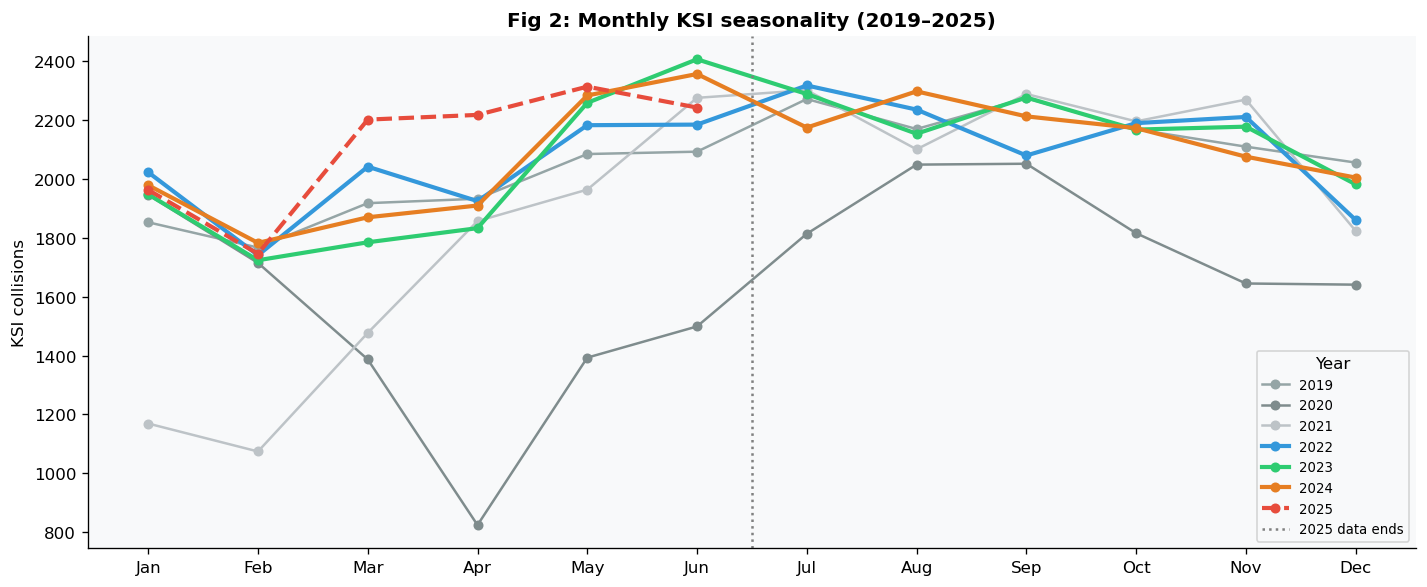

Saved: C:\Users\u2211111\outputs\fig_02_seasonality.png
Average H1 share (excl. COVID): 48.0%
2025 Jan–Jun KSI              : 12,686
2025 annualised estimate      : 26,446  (provisional — treat with caution)


<Figure size 768x576 with 0 Axes>

In [9]:
# 3.1 Seasonality check — validate 2025 annualisation
RECENT = [2019,2020,2021,2022,2023,2024,2025]
monthly = (col[col['collision_year'].isin(RECENT) & col['ksi']]
           .groupby(['collision_year','month']).size().reset_index(name='ksi_count'))
share = []
for yr in [2019,2020,2021,2022,2023,2024]:
    d  = monthly[monthly['collision_year']==yr]
    h1 = d[d['month']<=6]['ksi_count'].sum()
    share.append({'year':yr,'h1_pct':h1/d['ksi_count'].sum()*100})
share_df = pd.DataFrame(share)

fig, ax = plt.subplots(figsize=(12,5))
colors = ['#95a5a6','#7f8c8d','#bdc3c7','#3498db','#2ecc71','#e67e22','#e74c3c']
for i, yr in enumerate(RECENT):
    d = monthly[monthly['collision_year']==yr]
    ax.plot(d['month'], d['ksi_count'], marker='o', label=str(yr), color=colors[i],
            linestyle='--' if yr==2025 else '-',
            linewidth=2.5 if yr>=2022 else 1.5, markersize=5)
ax.axvline(6.5, color='grey', linestyle=':', linewidth=1.5, label='2025 data ends')
ax.set_xticks(range(1,13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_title('Fig 2: Monthly KSI seasonality (2019–2025)', fontweight='bold')
ax.set_ylabel('KSI collisions')
ax.legend(title='Year', fontsize=8)
plt.tight_layout(); savefig('fig_02_seasonality'); plt.show()

clean      = share_df[~share_df['year'].isin(COVID_YEARS)]
ann_factor = 100/clean['h1_pct'].mean()
ksi_h1     = monthly[monthly['collision_year']==2025]['ksi_count'].sum()
ksi_ann    = ksi_h1 * ann_factor
print(f'Average H1 share (excl. COVID): {clean["h1_pct"].mean():.1f}%')
print(f'2025 Jan–Jun KSI              : {ksi_h1:,}')
print(f'2025 annualised estimate      : {ksi_ann:,.0f}  (provisional — treat with caution)')


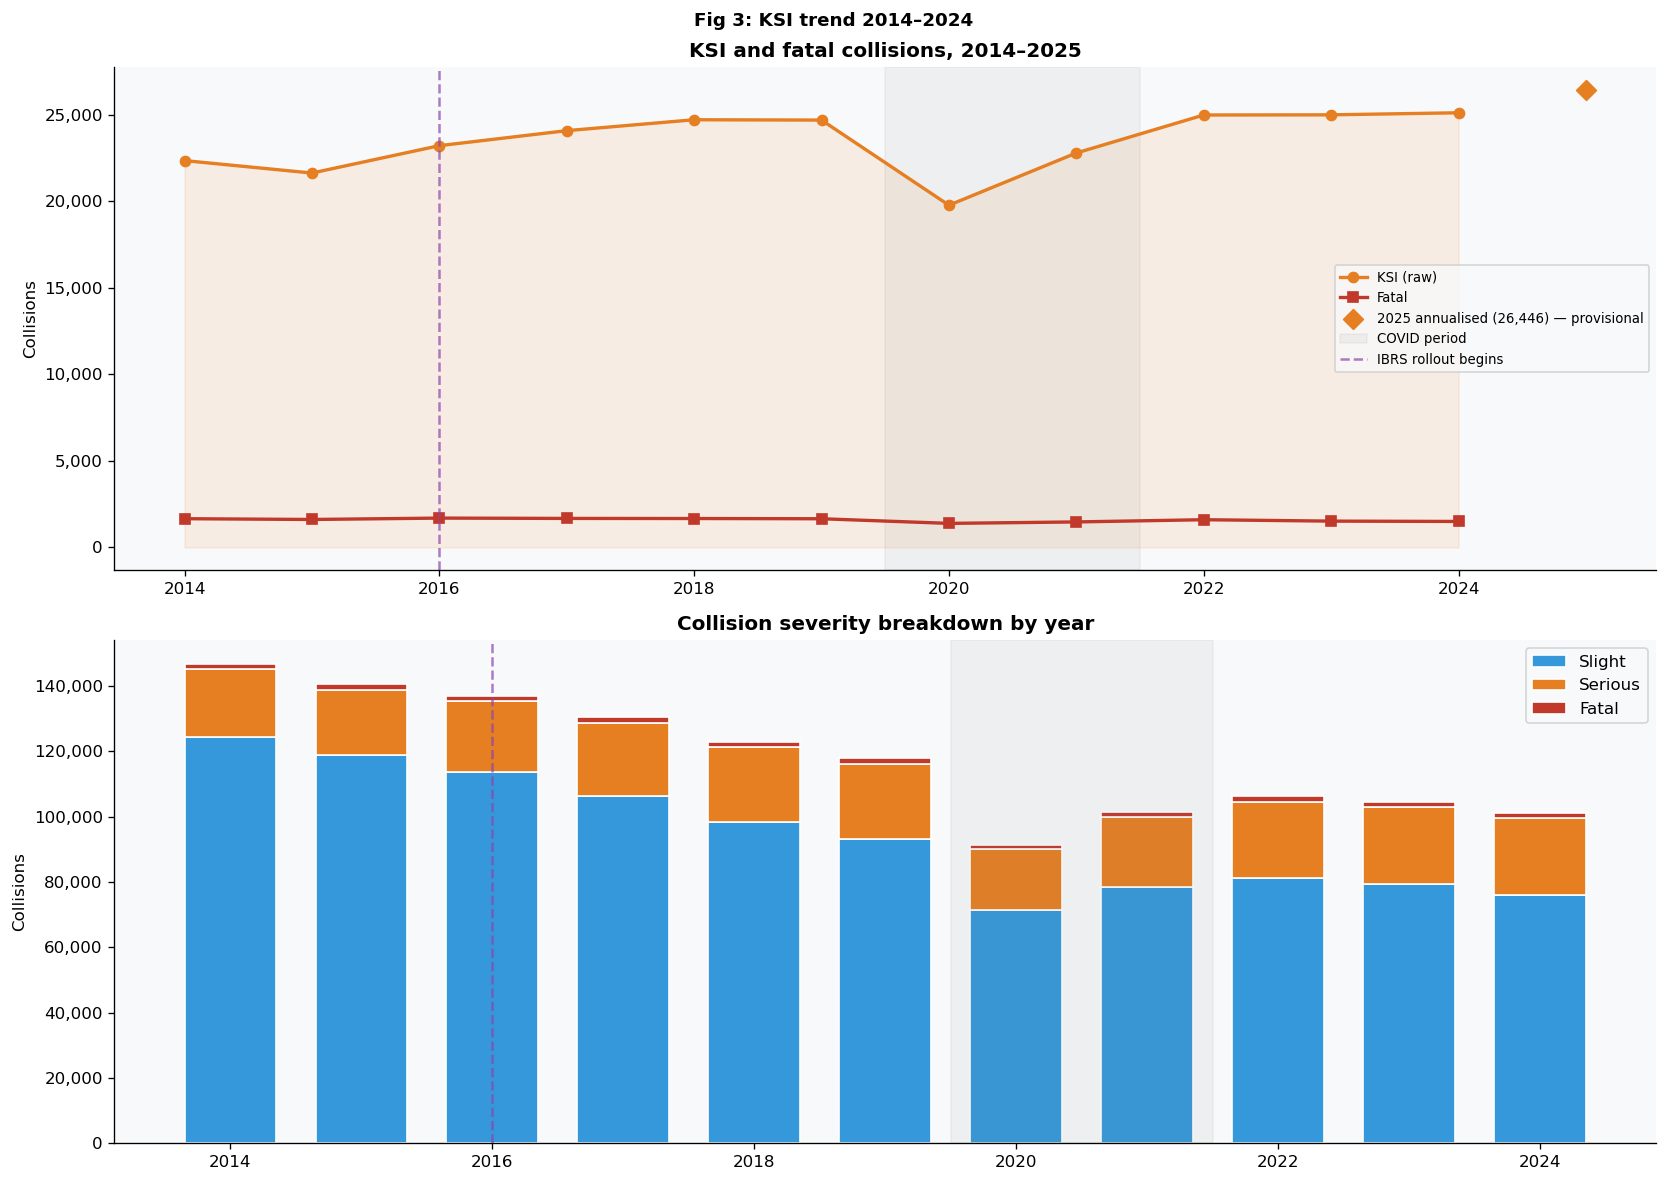

Saved: C:\Users\u2211111\outputs\fig_03_ksi_trend.png


<Figure size 768x576 with 0 Axes>

In [10]:
# 3.2 Long-term KSI trend
annual = (col[col['collision_year']<=2024]
          .groupby('collision_year')
          .agg(collisions=('collision_index','nunique'), ksi=('ksi','sum'), fatals=('fatal','sum'))
          .reset_index())

fig, axes = plt.subplots(2,1,figsize=(14,10))
ax = axes[0]
ax.fill_between(annual['collision_year'], annual['ksi'], alpha=0.10, color='#e67e22')
ax.plot(annual['collision_year'], annual['ksi'],    color='#e67e22', lw=2, marker='o', label='KSI (raw)')
ax.plot(annual['collision_year'], annual['fatals'], color='#c0392b', lw=2, marker='s', label='Fatal')
ax.scatter([2025],[ksi_ann], color='#e67e22', marker='D', s=70, zorder=5,
           label=f'2025 annualised ({ksi_ann:,.0f}) — provisional')
ax.axvspan(2019.5,2021.5, alpha=0.08, color='grey', label='COVID period')
ax.axvline(2016, color='#8e44ad', lw=1.5, linestyle='--', alpha=0.7, label='IBRS rollout begins')
ax.set_title('KSI and fatal collisions, 2014–2025', fontweight='bold')
ax.set_ylabel('Collisions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.legend(fontsize=8)

ax2 = axes[1]
by_sev = (col[col['collision_year'].between(2014,2024)]
          .groupby(['collision_year','collision_severity']).size().unstack(fill_value=0)
          .rename(columns={1:'Fatal',2:'Serious',3:'Slight'}))
bottom = np.zeros(len(by_sev))
for sev, color in [('Slight','#3498db'),('Serious','#e67e22'),('Fatal','#c0392b')]:
    if sev in by_sev.columns:
        ax2.bar(by_sev.index, by_sev[sev], bottom=bottom, color=color, label=sev, edgecolor='white', width=0.7)
        bottom += by_sev[sev].values
ax2.axvspan(2019.5,2021.5, alpha=0.08, color='grey')
ax2.axvline(2016, color='#8e44ad', lw=1.5, linestyle='--', alpha=0.7)
ax2.set_title('Collision severity breakdown by year', fontweight='bold')
ax2.set_ylabel('Collisions')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax2.legend()
plt.suptitle('Fig 3: KSI trend 2014–2024', fontweight='bold', fontsize=11)
plt.tight_layout(); savefig('fig_03_ksi_trend'); plt.show()


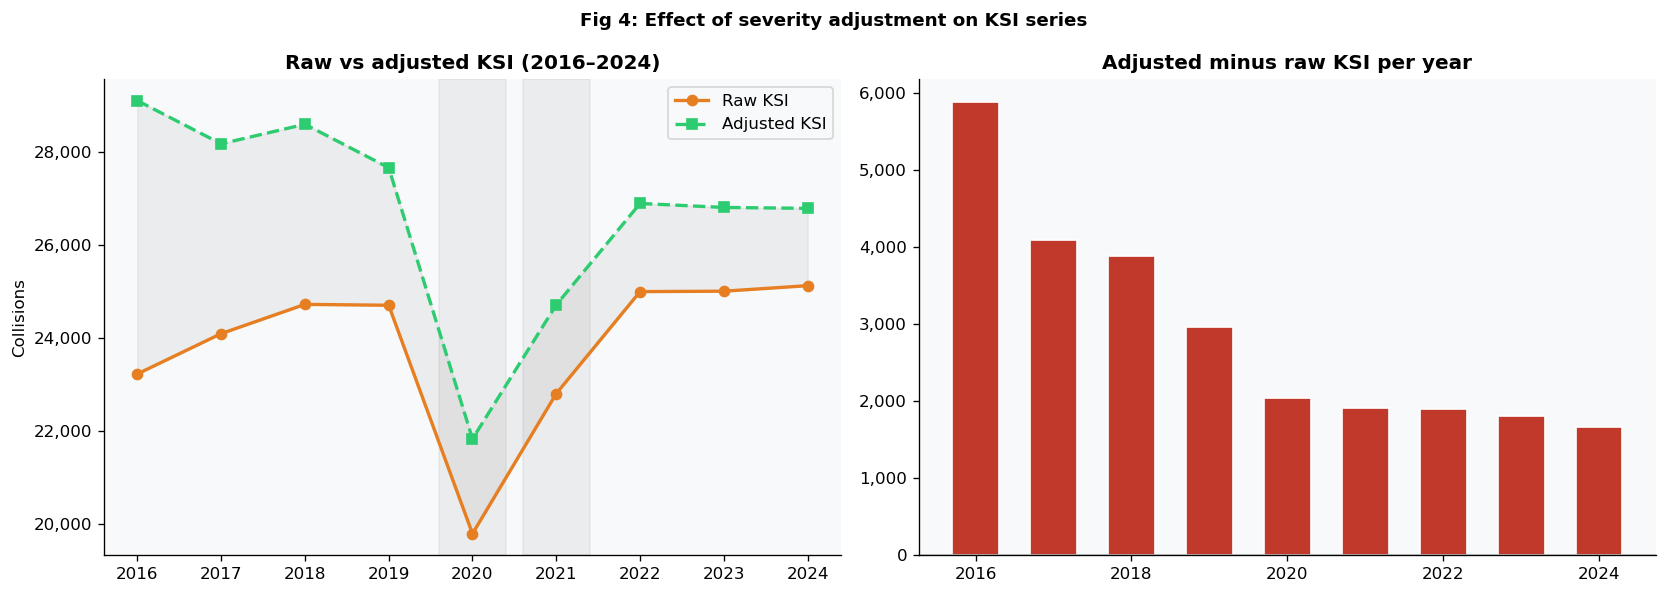

Saved: C:\Users\u2211111\outputs\fig_04_raw_vs_adjusted.png
 collision_year  raw_ksi      adj_ksi  ibrs_pct
           2016    23222 29108.430432      31.2
           2017    24090 28178.597669      35.6
           2018    24720 28599.768234      35.2
           2019    24701 27663.544498      42.3
           2020    19781 21823.632978      45.0
           2021    22799 24710.214204      49.7
           2022    24995 26893.958525      52.6
           2023    25004 26808.394853      53.8
           2024    25123 26788.669491      58.8


<Figure size 768x576 with 0 Axes>

In [11]:
# 3.3 Raw vs IBRS-adjusted KSI
ibrs_w = col[(col['collision_year']>=2016) & (col['collision_year']<=2024) & (~col['provisional'])].copy()
adj = ibrs_w.groupby('collision_year').agg(
    raw_fatal   = ('fatal','sum'),
    raw_serious = ('collision_severity', lambda x: (x==2).sum()),
    adj_serious = ('collision_adjusted_severity_serious','sum'),
    ibrs_pct    = ('collision_injury_based', lambda x: (x==1).sum()/len(x)*100)
).reset_index()
adj['raw_ksi'] = adj['raw_fatal'] + adj['raw_serious']
adj['adj_ksi'] = adj['raw_fatal'] + adj['adj_serious']
adj['ibrs_pct'] = adj['ibrs_pct'].round(1)

fig, axes = plt.subplots(1,2,figsize=(14,5))
ax = axes[0]
ax.plot(adj['collision_year'], adj['raw_ksi'], marker='o', color='#e67e22', lw=2, label='Raw KSI')
ax.plot(adj['collision_year'], adj['adj_ksi'], marker='s', color='#2ecc71', lw=2,
        linestyle='--', label='Adjusted KSI')
ax.fill_between(adj['collision_year'], adj['raw_ksi'], adj['adj_ksi'], alpha=0.1, color='grey')
for yr in COVID_YEARS:
    ax.axvspan(yr-0.4,yr+0.4, alpha=0.1, color='grey')
ax.set_title('Raw vs adjusted KSI (2016–2024)', fontweight='bold')
ax.set_ylabel('Collisions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.legend()

ax2 = axes[1]
gap = adj['adj_ksi'] - adj['raw_ksi']
ax2.bar(adj['collision_year'], gap,
        color=['#c0392b' if d>0 else '#2ecc71' for d in gap], width=0.6, edgecolor='white')
ax2.axhline(0, color='black', lw=0.8)
ax2.set_title('Adjusted minus raw KSI per year', fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.suptitle('Fig 4: Effect of severity adjustment on KSI series', fontweight='bold', fontsize=11)
plt.tight_layout(); savefig('fig_04_raw_vs_adjusted'); plt.show()

adj[['collision_year','raw_serious','adj_serious','raw_ksi','adj_ksi','ibrs_pct']].to_csv(
    os.path.join(OUTPUT_DIR,'tab_raw_vs_adjusted_ksi.csv'), index=False)
print(adj[['collision_year','raw_ksi','adj_ksi','ibrs_pct']].to_string(index=False))


---
## 4. Road User Severity Profile (2016–2024)

Uses 2016–2024 to align with the IBRS period. Analysis at casualty level —
one seriously injured person in a collision with three casualties counts as one.
`casualty_type = 0` (not in STATS19 codebook) treated as Unknown throughout.


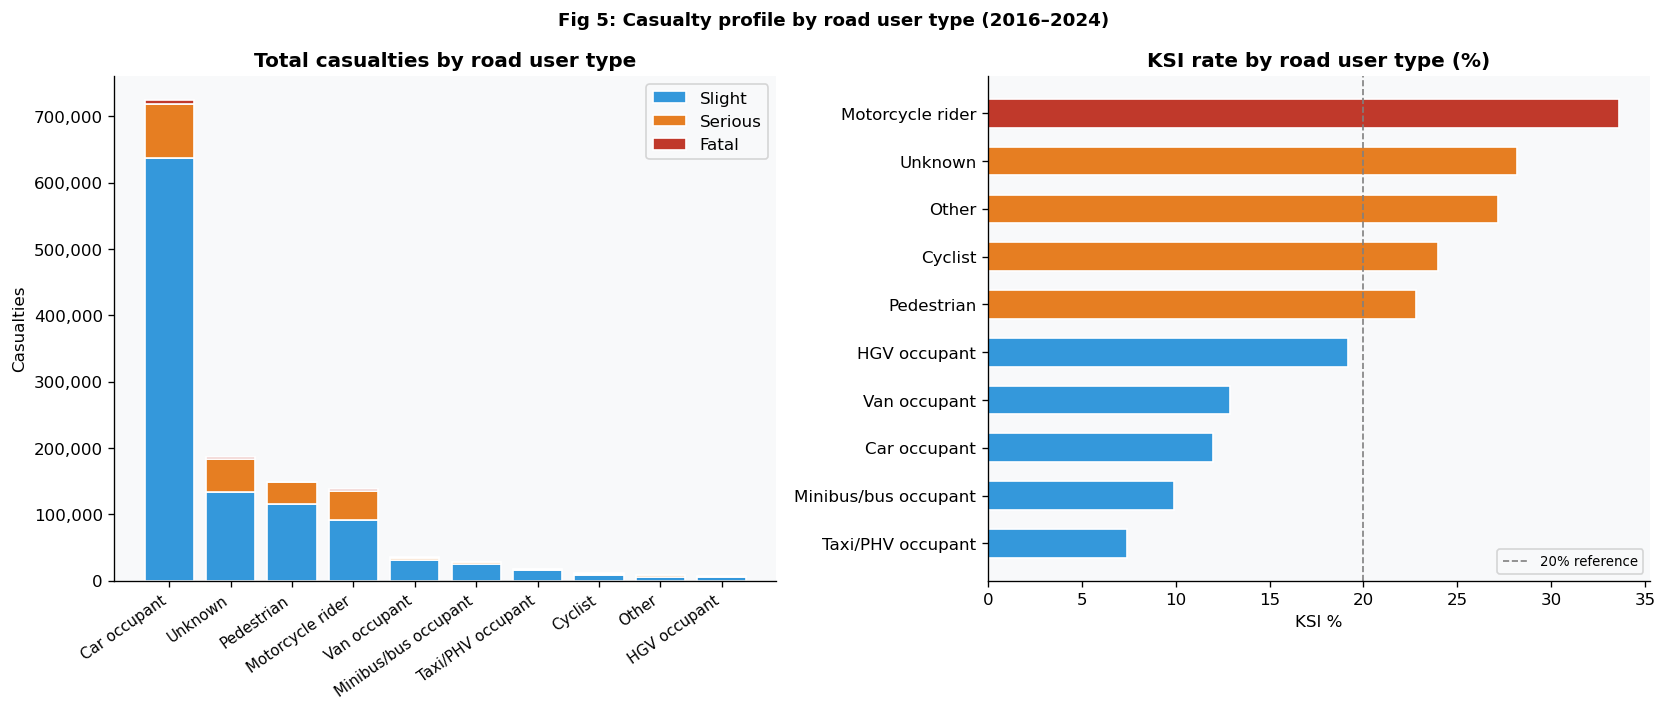

Saved: C:\Users\u2211111\outputs\fig_05_road_user_severity.png
casualty_severity     Fatal  Serious  Slight   Total    KSI  KSI%  Fatal%
road_user                                                                
Car occupant           6516    80772  637360  724648  87288  12.0    0.90
Unknown                3796    49002  134345  187143  52798  28.2    2.03
Pedestrian              914    33050  115260  149224  33964  22.8    0.61
Motorcycle rider       2915    43744   92160  138819  46659  33.6    2.10
Van occupant            361     4172   30558   35091   4533  12.9    1.03
Minibus/bus occupant     85     2644   24837   27566   2729   9.9    0.31
Taxi/PHV occupant        77     1242   16612   17931   1319   7.4    0.43
Cyclist                  43     2568    8274   10885   2611  24.0    0.40
Other                   213     2005    5933    8151   2218  27.2    2.61
HGV occupant            156     1229    5811    7196   1385  19.2    2.17


<Figure size 768x576 with 0 Axes>

In [12]:
prov_map = col.drop_duplicates('collision_index').set_index('collision_index')['provisional']
cas_w = cas.copy()
cas_w['provisional'] = cas_w['collision_index'].map(prov_map).fillna(False)
window = cas_w[(cas_w['collision_year']>=2016) & (cas_w['collision_year']<=2024) & (~cas_w['provisional'])].copy()

ru = window.groupby('road_user')['casualty_severity'].value_counts().unstack(fill_value=0)
ru = ru.rename(columns={1:'Fatal',2:'Serious',3:'Slight'})
for c in ['Fatal','Serious','Slight']:
    if c not in ru.columns: ru[c] = 0
ru['Total'] = ru['Fatal']+ru['Serious']+ru['Slight']
ru['KSI']   = ru['Fatal']+ru['Serious']
ru['KSI%']  = (ru['KSI']/ru['Total']*100).round(1)
ru['Fatal%'] = (ru['Fatal']/ru['Total']*100).round(2)
ru = ru.sort_values('Total', ascending=False)

fig, axes = plt.subplots(1,2,figsize=(14,6))
ax = axes[0]
top = ru[ru['Total']>1000].copy()
bottom = np.zeros(len(top))
for sev, color in [('Slight','#3498db'),('Serious','#e67e22'),('Fatal','#c0392b')]:
    ax.bar(range(len(top)), top[sev], bottom=bottom, color=color, label=sev, edgecolor='white')
    bottom += top[sev].values
ax.set_xticks(range(len(top)))
ax.set_xticklabels(top.index, rotation=35, ha='right', fontsize=9)
ax.set_title('Total casualties by road user type', fontweight='bold')
ax.set_ylabel('Casualties')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.legend()

ax2 = axes[1]
ksi_plot = ru[ru['Total']>1000].sort_values('KSI%', ascending=True)
bar_colors = ['#c0392b' if k>30 else '#e67e22' if k>20 else '#3498db' for k in ksi_plot['KSI%']]
ax2.barh(ksi_plot.index, ksi_plot['KSI%'], color=bar_colors, edgecolor='white', height=0.6)
ax2.axvline(20, color='grey', linestyle='--', lw=1, label='20% reference')
ax2.set_title('KSI rate by road user type (%)', fontweight='bold')
ax2.set_xlabel('KSI %')
ax2.legend(fontsize=8)
plt.suptitle('Fig 5: Casualty profile by road user type (2016–2024)', fontweight='bold', fontsize=11)
plt.tight_layout(); savefig('fig_05_road_user_severity'); plt.show()

ru[['Fatal','Serious','Slight','Total','KSI','KSI%','Fatal%']].to_csv(
    os.path.join(OUTPUT_DIR,'tab_road_user_severity.csv'))
print(ru[['Fatal','Serious','Slight','Total','KSI','KSI%','Fatal%']].to_string())


---
## 5. Geographic Hotspot Analysis (2022–2024)

Two hotspot definitions compared: raw KSI count and KSI rate per collision.
The count definition identifies areas with high road exposure; the rate
definition identifies areas where collisions are most likely to result in
serious injury. Both are shown because they imply different intervention strategies.


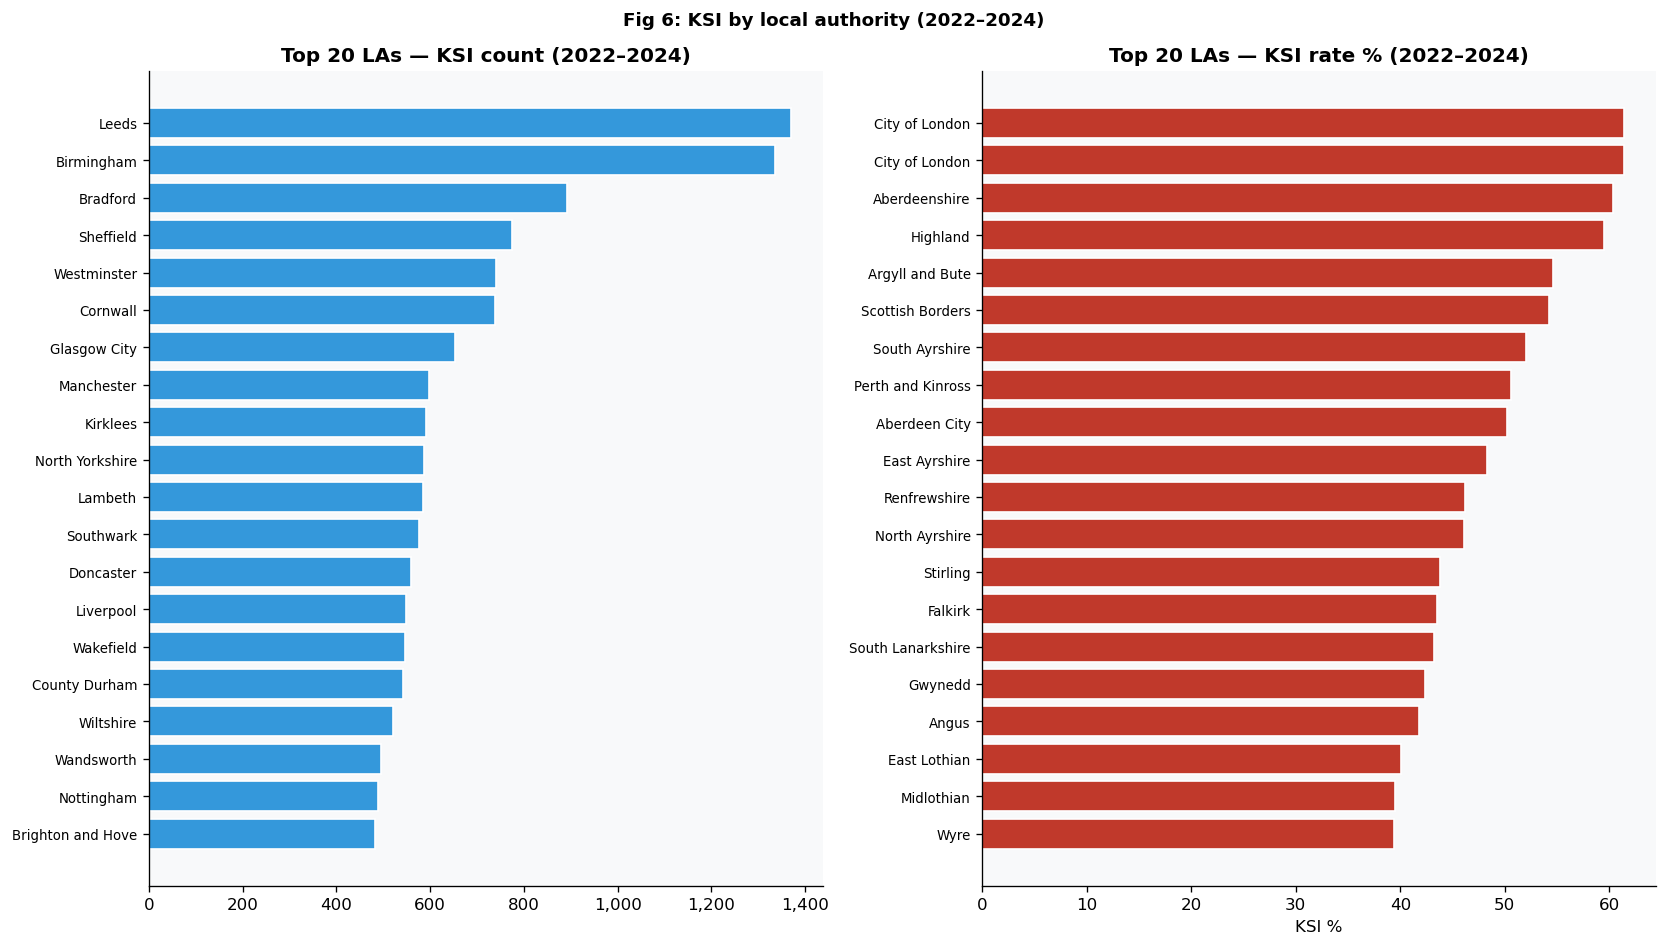

Saved: C:\Users\u2211111\outputs\fig_06_la_hotspots.png


<Figure size 768x576 with 0 Axes>

In [36]:
hot = col[(col['collision_year']>=2022) & (col['collision_year']<=2024)].copy()

la = hot.groupby('local_authority_ons_district').agg(
    collisions=('collision_index','nunique'), ksi=('ksi','sum'), fatals=('fatal','sum')
).reset_index()
la['ksi_pct']   = (la['ksi']/la['collisions']*100).round(1)
la['fatal_pct'] = (la['fatals']/la['collisions']*100).round(2)
la = la.merge(la_lookup, on='local_authority_ons_district', how='left')
la['la_name'] = la['la_name'].fillna(la['local_authority_ons_district'])
la = la.sort_values('ksi', ascending=False)

fig, axes = plt.subplots(1,2,figsize=(14,8))
top20 = la.head(20).sort_values('ksi')
axes[0].barh(range(len(top20)), top20['ksi'], color='#3498db', edgecolor='white')
axes[0].set_yticks(range(len(top20)))
axes[0].set_yticklabels(top20['la_name'], fontsize=8)
axes[0].set_title('Top 20 LAs — KSI count (2022–2024)', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

la_rate = la[la['collisions']>200].sort_values('ksi_pct', ascending=False).head(20).sort_values('ksi_pct')
axes[1].barh(range(len(la_rate)), la_rate['ksi_pct'], color='#c0392b', edgecolor='white')
axes[1].set_yticks(range(len(la_rate)))
axes[1].set_yticklabels(la_rate['la_name'], fontsize=8)
axes[1].set_title('Top 20 LAs — KSI rate % (2022–2024)', fontweight='bold')
axes[1].set_xlabel('KSI %')

plt.suptitle('Fig 6: KSI by local authority (2022–2024)', fontweight='bold', fontsize=11)
plt.tight_layout(); savefig('fig_06_la_hotspots'); plt.show()
la.to_csv(os.path.join(OUTPUT_DIR,'tab_la_hotspots.csv'), index=False)


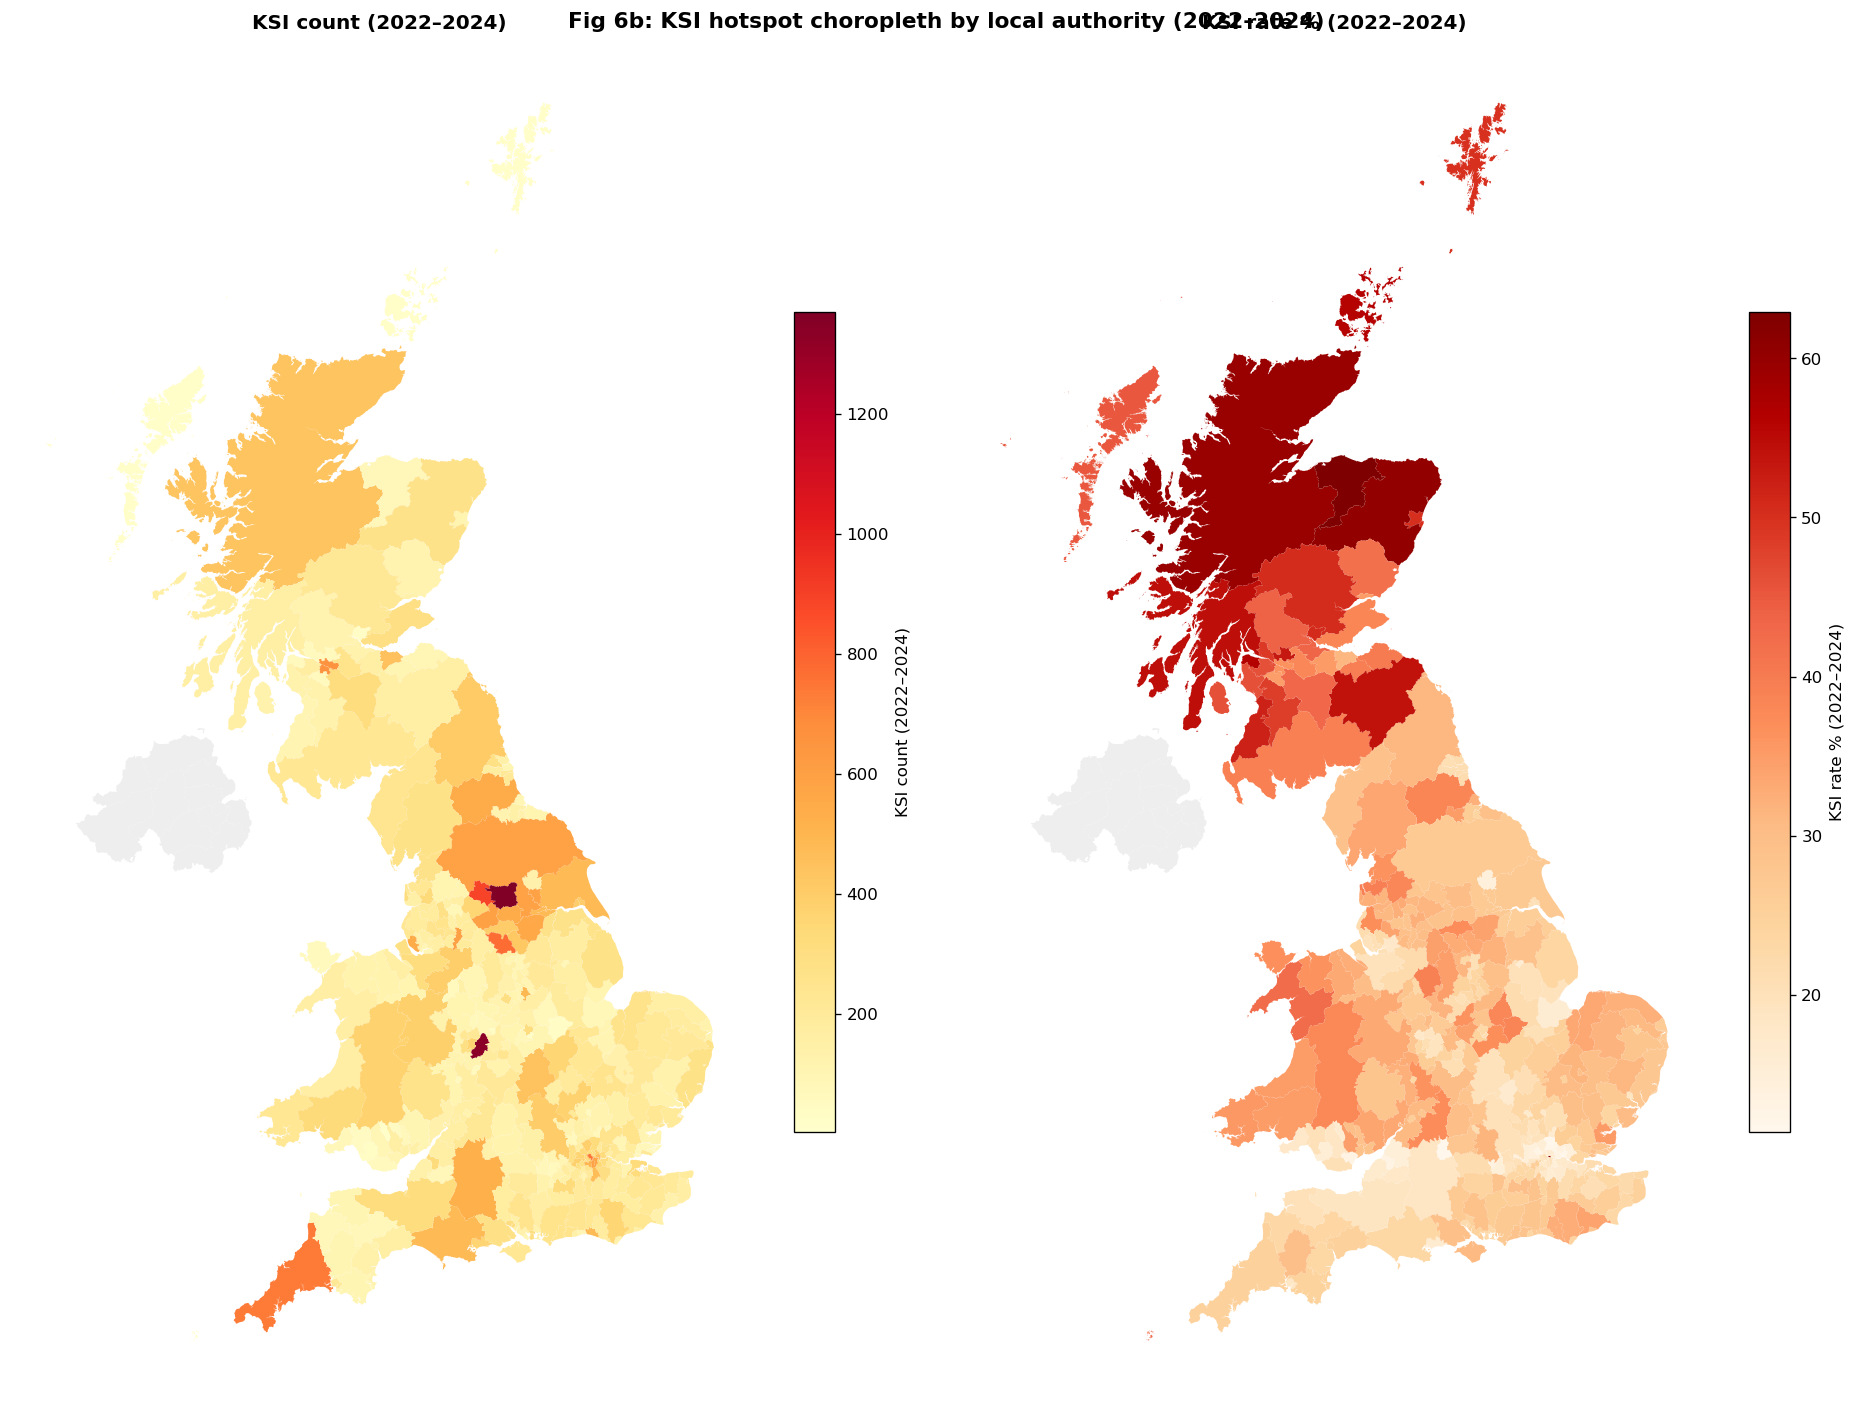

Saved: C:\Users\u2211111\outputs\fig_06b_choropleth.png


<Figure size 768x576 with 0 Axes>

In [37]:
# Choropleth map — KSI by local authority
import geopandas as gpd

la_url = ('https://services1.arcgis.com/ESMARspQHYMw9BZ9/arcgis/rest/services/'
          'Local_Authority_Districts_December_2024_Boundaries_UK_BGC/FeatureServer/0/query'
          '?where=1%3D1&outFields=LAD24CD,LAD24NM&outSR=4326&f=geojson')
la_geo = gpd.read_file(la_url)
la_geo = la_geo.merge(la, left_on='LAD24CD',
                      right_on='local_authority_ons_district', how='left')

fig, axes = plt.subplots(1, 2, figsize=(16, 12))
for ax, col_name, title, cmap in [
    (axes[0], 'ksi',     'KSI count (2022–2024)',  'YlOrRd'),
    (axes[1], 'ksi_pct', 'KSI rate % (2022–2024)', 'OrRd'),
]:
    la_geo.plot(column=col_name, ax=ax, cmap=cmap, legend=True,
                missing_kwds={'color': '#eeeeee'},
                legend_kwds={'shrink': 0.6, 'label': title})
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_axis_off()
plt.suptitle('Fig 6b: KSI hotspot choropleth by local authority (2022–2024)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
savefig('fig_06b_choropleth')
plt.show()

---
## 6. Contributory Factors (2022–2024)

Four contributory factors are examined: urban/rural setting, speed limit, road type, and junction type. Time patterns (day and hour) are also included. Both count and KSI rate are shown throughout — count reflects road exposure while rate reflects injury risk. The distinction matters for intervention targeting: high count may reflect high traffic volume rather than high risk.


In [14]:
ur = (hot.groupby('ur_label')['collision_severity']
      .value_counts().unstack(fill_value=0)
      .rename(columns={1:'Fatal',2:'Serious',3:'Slight'}))
for c in ['Fatal','Serious','Slight']:
    if c not in ur.columns: ur[c] = 0
ur['Total']  = ur['Fatal']+ur['Serious']+ur['Slight']
ur['KSI']    = ur['Fatal']+ur['Serious']
ur['KSI%']   = (ur['KSI']/ur['Total']*100).round(1)
ur['Fatal%'] = (ur['Fatal']/ur['Total']*100).round(2)
print('Urban vs Rural KSI breakdown (2022–2024):')
display(ur[['Fatal','Serious','Slight','Total','KSI','KSI%','Fatal%']])
ur[['Fatal','Serious','Slight','Total','KSI','KSI%','Fatal%']].to_csv(
    os.path.join(OUTPUT_DIR,'tab_urban_rural.csv'))


Urban vs Rural KSI breakdown (2022–2024):


collision_severity,Fatal,Serious,Slight,Total,KSI,KSI%,Fatal%
ur_label,,,,,,,
Rural,2924,26836,72021,101781,29760,29.2,2.87
Unallocated,0,8,21,29,8,27.6,0.00
Urban,1704,43648,164534,209886,45352,21.6,0.81


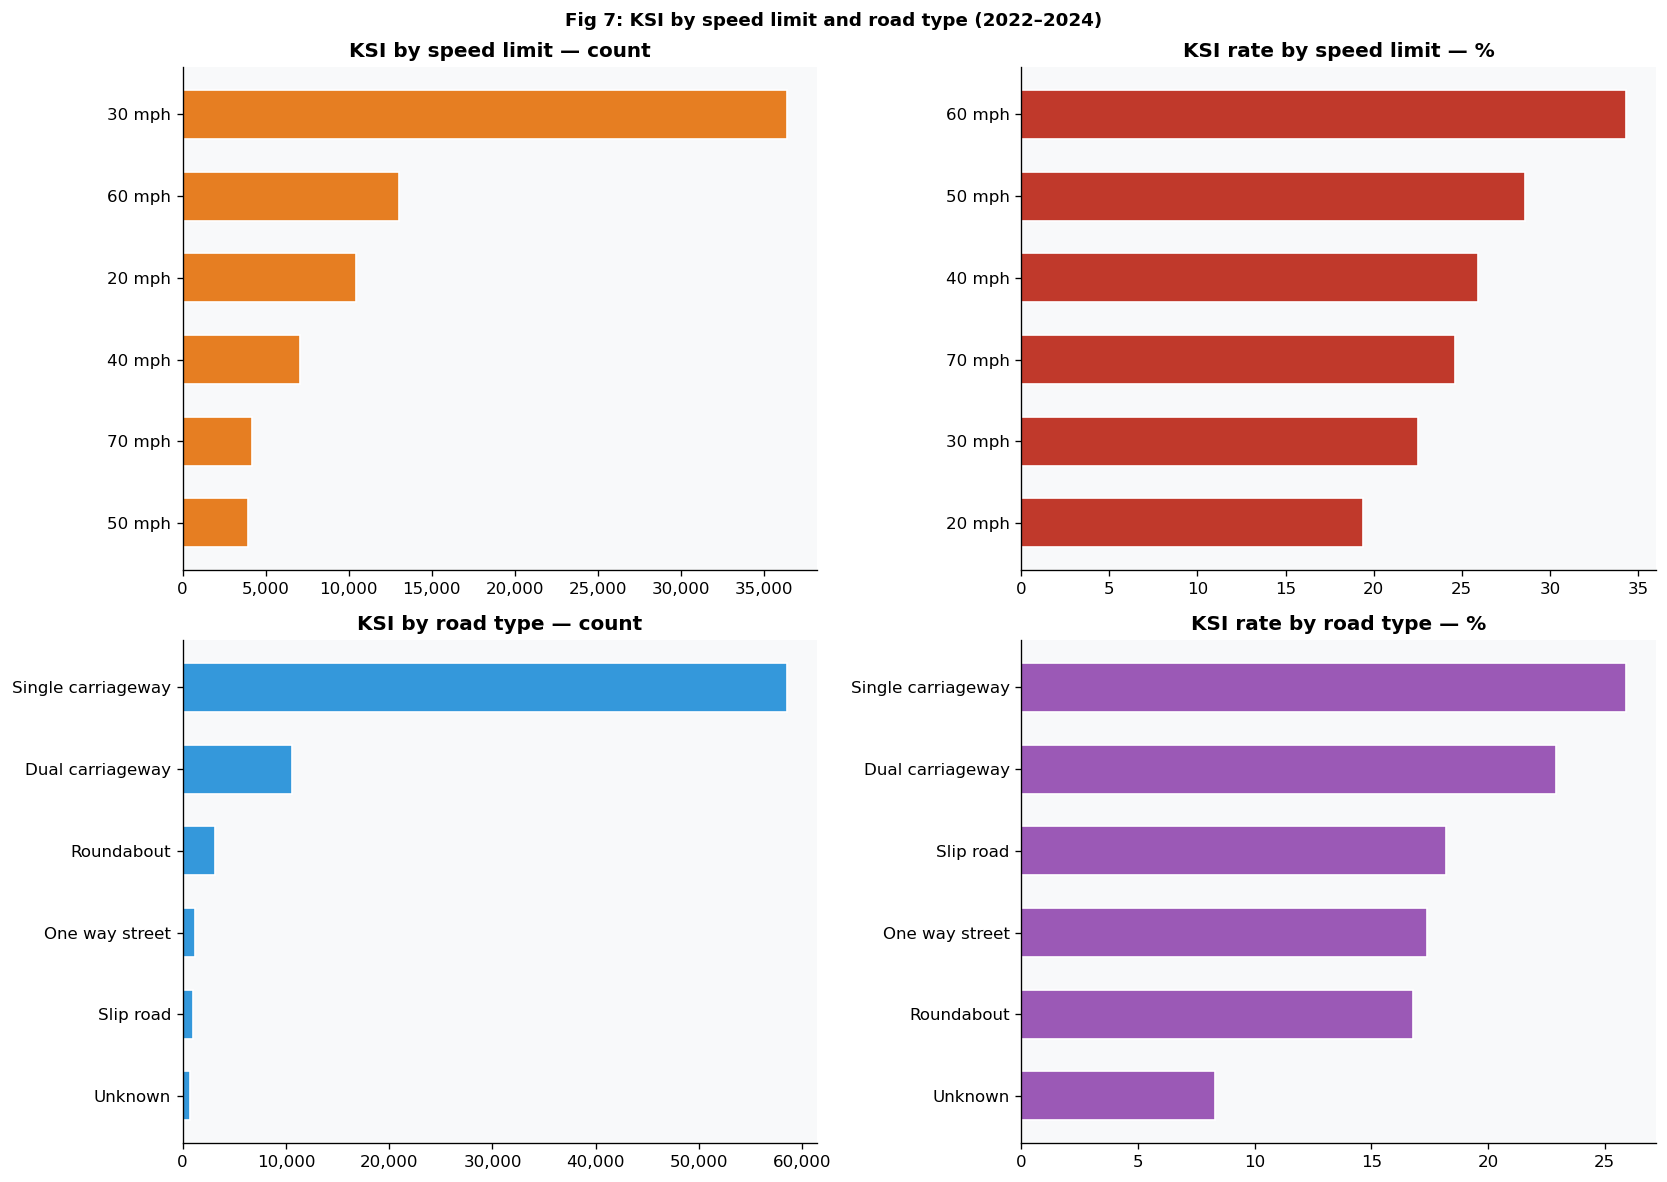

Saved: C:\Users\u2211111\outputs\fig_07_speed_road_type.png


<Figure size 768x576 with 0 Axes>

In [15]:
fig, axes = plt.subplots(2,2,figsize=(14,10))

speed = (hot[hot['speed_limit'].notna()]
         .groupby('speed_limit')['collision_severity']
         .value_counts().unstack(fill_value=0)
         .rename(columns={1:'Fatal',2:'Serious',3:'Slight'}))
for c in ['Fatal','Serious','Slight']:
    if c not in speed.columns: speed[c] = 0
speed['KSI']   = speed['Fatal']+speed['Serious']
speed['Total'] = speed['Fatal']+speed['Serious']+speed['Slight']
speed['KSI%']  = (speed['KSI']/speed['Total']*100).round(1)

s = speed.sort_values('KSI', ascending=True)
axes[0,0].barh([f'{int(x)} mph' for x in s.index], s['KSI'], color='#e67e22', edgecolor='white', height=0.6)
axes[0,0].set_title('KSI by speed limit — count', fontweight='bold')
axes[0,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

sr = speed.sort_values('KSI%', ascending=True)
axes[0,1].barh([f'{int(x)} mph' for x in sr.index], sr['KSI%'], color='#c0392b', edgecolor='white', height=0.6)
axes[0,1].set_title('KSI rate by speed limit — %', fontweight='bold')

rc = (hot[hot['road_type_label'].notna()]
      .groupby('road_type_label')['collision_severity']
      .value_counts().unstack(fill_value=0)
      .rename(columns={1:'Fatal',2:'Serious',3:'Slight'}))
for c in ['Fatal','Serious','Slight']:
    if c not in rc.columns: rc[c] = 0
rc['KSI']   = rc['Fatal']+rc['Serious']
rc['Total'] = rc['Fatal']+rc['Serious']+rc['Slight']
rc['KSI%']  = (rc['KSI']/rc['Total']*100).round(1)

r = rc.sort_values('KSI', ascending=True)
axes[1,0].barh(r.index, r['KSI'], color='#3498db', edgecolor='white', height=0.6)
axes[1,0].set_title('KSI by road type — count', fontweight='bold')
axes[1,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

rr = rc.sort_values('KSI%', ascending=True)
axes[1,1].barh(rr.index, rr['KSI%'], color='#9b59b6', edgecolor='white', height=0.6)
axes[1,1].set_title('KSI rate by road type — %', fontweight='bold')

plt.suptitle('Fig 7: KSI by speed limit and road type (2022–2024)', fontweight='bold', fontsize=11)
plt.tight_layout(); savefig('fig_07_speed_road_type'); plt.show()


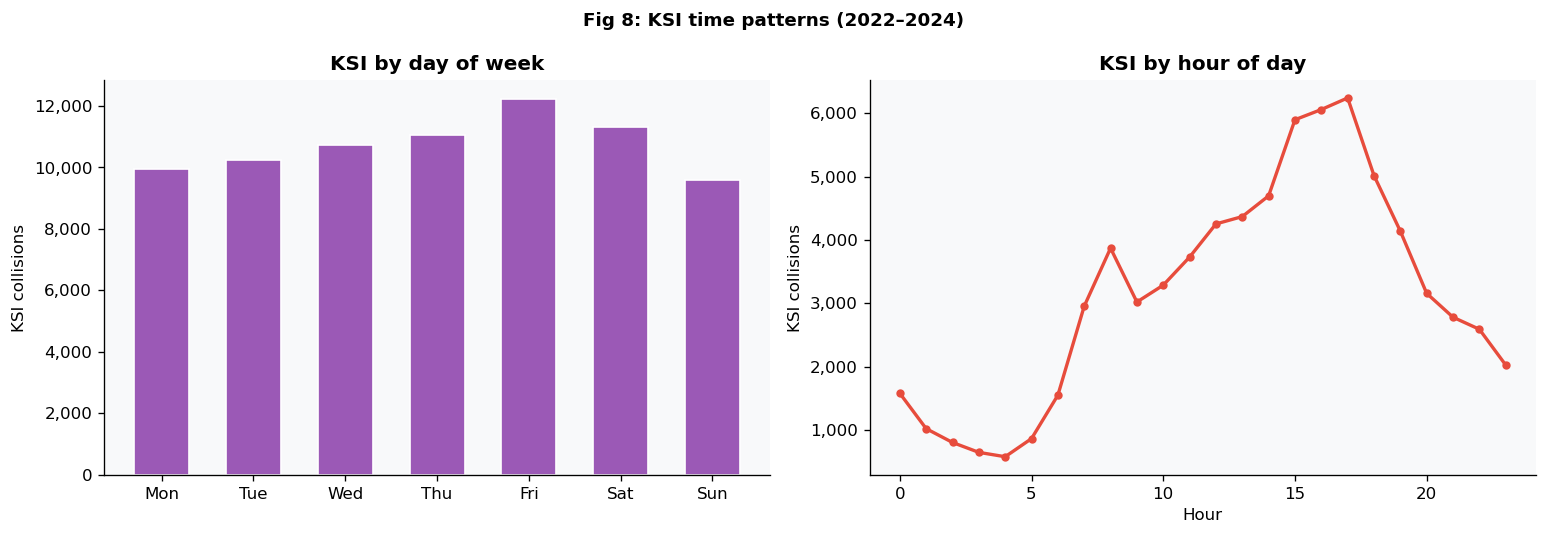

Saved: C:\Users\u2211111\outputs\fig_08_time_patterns.png


<Figure size 768x576 with 0 Axes>

In [16]:
fig, axes = plt.subplots(1,2,figsize=(13,4.5))
day_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
day = (hot[hot['day_label'].notna() & hot['ksi']].groupby('day_label').size().reindex(day_order))
axes[0].bar(day.index, day.values, color='#9b59b6', edgecolor='white', width=0.6)
axes[0].set_title('KSI by day of week', fontweight='bold')
axes[0].set_ylabel('KSI collisions')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

hot_h = hot[hot['ksi']].copy()
hot_h['hour'] = pd.to_datetime(hot_h['time'], format='%H:%M', errors='coerce').dt.hour
hour = hot_h.groupby('hour').size()
axes[1].plot(hour.index, hour.values, color='#e74c3c', lw=2, marker='o', markersize=4)
axes[1].set_title('KSI by hour of day', fontweight='bold')
axes[1].set_xlabel('Hour'); axes[1].set_ylabel('KSI collisions')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.suptitle('Fig 8: KSI time patterns (2022–2024)', fontweight='bold', fontsize=11)
plt.tight_layout(); savefig('fig_08_time_patterns'); plt.show()


### 6.4 Junction Type

Junction type is examined to understand whether KSI collisions are concentrated at specific junction configurations or on open road sections. This has direct implications for whether junction redesign is an appropriate intervention.


In [ ]:
# 6.4 Junction type breakdown
jn = hot[hot['junction_detail'].notna()].copy()
jn['junction_label'] = jn['junction_detail'].astype(int).map(JUNCTION_MAP)
jn = jn[jn['junction_label'].notna()]

jn_grp = (jn.groupby('junction_label')['collision_severity']
          .value_counts().unstack(fill_value=0)
          .rename(columns={1:'Fatal',2:'Serious',3:'Slight'}))
for c in ['Fatal','Serious','Slight']:
    if c not in jn_grp.columns: jn_grp[c] = 0
jn_grp['KSI']   = jn_grp['Fatal'] + jn_grp['Serious']
jn_grp['Total'] = jn_grp['Fatal'] + jn_grp['Serious'] + jn_grp['Slight']
jn_grp['KSI%']  = (jn_grp['KSI'] / jn_grp['Total'] * 100).round(1)
jn_grp = jn_grp.sort_values('KSI', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
jn_count = jn_grp.sort_values('KSI', ascending=True)
axes[0].barh(jn_count.index, jn_count['KSI'], color='#3498db', edgecolor='white', height=0.6)
axes[0].set_title('KSI by junction type — count', fontweight='bold')
axes[0].set_xlabel('KSI collisions')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

jn_rate = jn_grp.sort_values('KSI%', ascending=True)
axes[1].barh(jn_rate.index, jn_rate['KSI%'], color='#9b59b6', edgecolor='white', height=0.6)
axes[1].set_title('KSI rate by junction type — %', fontweight='bold')
axes[1].set_xlabel('KSI %')

plt.suptitle('Fig 9: KSI by junction type (2022–2024)', fontweight='bold', fontsize=11)
plt.tight_layout(); savefig('fig_09_junction_type'); plt.show()

jn_grp[['Fatal','Serious','Slight','Total','KSI','KSI%']].to_csv(
    os.path.join(OUTPUT_DIR,'tab_junction_type.csv'))
print('KSI by junction type (2022–2024):')
print(jn_grp[['Fatal','Serious','Slight','Total','KSI','KSI%']].to_string())


---
## 7. Local Authority Trend Analysis (2014–2024)

OLS regression of annual KSI casualty count on year, fitted separately per local authority. The slope estimates the annual rate of change in KSI casualties. 95% confidence intervals are computed to identify authorities where the trend direction is statistically clear. A secondary method (3-year average comparison: 2015–17 vs 2022–24) is used as a cross-check — the two methods agree on direction for 88% of authorities.

**Key design decisions:** (1) Casualties not collisions — one collision with three seriously injured people counts as three. (2) 53 LAs excluded due to boundary reorganisations mid-window (e.g. North Yorkshire April 2023). (3) R² threshold of 0.5 used to distinguish sustained linear trends from spike/V-shape patterns. (4) COVID years (2020–21) included in the regression window but flagged — their influence on slopes is quantified in Section 9.


In [17]:
cas_full = pd.read_csv(CAS_FULL, dtype={'collision_index':str}, low_memory=False)
ksi = cas_full[
    cas_full['ksi'].eq(True) &
    cas_full['provisional'].eq(False) &
    cas_full['la_name'].notna()
].copy()
print(f'KSI casualties loaded: {len(ksi):,}')
print(f'Years: {sorted(ksi["collision_year"].dropna().unique().astype(int).tolist())}')


KSI casualties loaded: 360,128
Years: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


In [18]:
def complete_las(df, years):
    return set(
        df[df['collision_year'].isin(years)]
        .groupby('la_name')['collision_year'].nunique()
        .pipe(lambda s: s[s==len(years)].index)
    )

complete     = complete_las(ksi, BASE_YEARS) & complete_las(ksi, RECENT_YEARS)
ksi_complete = ksi[ksi['la_name'].isin(complete)].copy()
print(f'LAs with complete data : {len(complete)}')
print(f'LAs excluded           : {ksi["la_name"].nunique() - len(complete)}')

annual = (ksi_complete.groupby(['la_name','collision_year'])
          .size().reset_index(name='KSI'))


LAs with complete data : 339
LAs excluded           : 53


In [19]:
# OLS per LA with 95% confidence intervals
ols_rows = []
for la, grp in annual.groupby('la_name'):
    grp = grp.dropna(subset=['KSI','collision_year'])
    if len(grp) < MIN_YEARS:
        continue
    x = grp['collision_year'].values
    y = grp['KSI'].values
    slope, intercept, r, p, se = stats.linregress(x, y)
    # 95% CI on slope
    t_crit = stats.t.ppf(0.975, df=len(x)-2)
    ci_lower = slope - t_crit * se
    ci_upper = slope + t_crit * se
    ols_rows.append({
        'la_name'   : la,
        'slope'     : slope,
        'ci_lower'  : ci_lower,
        'ci_upper'  : ci_upper,
        'se'        : se,
        'intercept' : intercept,
        'r_squared' : r**2,
        'p_value'   : p,
        'n_years'   : len(grp),
        'mean_ksi'  : y.mean(),
    })

ols = pd.DataFrame(ols_rows)
ols = ols[ols['mean_ksi'] >= MIN_KSI_BASE].copy()
ols['trend_shape'] = ols['r_squared'].apply(lambda r: 'Linear' if r>=LOW_R2 else 'Non-linear')
ols['ci_includes_zero'] = (ols['ci_lower'] < 0) & (ols['ci_upper'] > 0)

# 3-year average secondary check
def window_avg(df, years):
    return (df[df['collision_year'].isin(years)].groupby('la_name')
            .size().div(len(years)).reset_index(name='ksi_avg'))

base   = window_avg(ksi_complete, BASE_YEARS).rename(columns={'ksi_avg':'base_avg'})
recent = window_avg(ksi_complete, RECENT_YEARS).rename(columns={'ksi_avg':'recent_avg'})
avg_chg = base.merge(recent, on='la_name')
avg_chg['avg_pct_change'] = (avg_chg['recent_avg']-avg_chg['base_avg'])/avg_chg['base_avg']*100
ols = ols.merge(avg_chg[['la_name','base_avg','recent_avg','avg_pct_change']], on='la_name', how='left')
ols['methods_agree'] = (ols['slope']>0) == (ols['avg_pct_change']>0)

print(f'LAs fitted           : {len(ols)}')
print(f'Linear (R² >= {LOW_R2}): {(ols["r_squared"]>=LOW_R2).sum()}')
print(f'CI includes zero     : {ols["ci_includes_zero"].sum()} LAs (slope not stat. significant)')
print(f'Methods agree        : {ols["methods_agree"].sum()} / {len(ols)}')

ols.to_csv(os.path.join(OUTPUT_DIR,'tab_la_ols_results.csv'), index=False)


LAs fitted           : 323
Linear (R² >= 0.5): 38
CI includes zero     : 252 LAs (slope not stat. significant)
Methods agree        : 284 / 323


In [20]:
# Worsening LAs
worsening = ols[ols['slope']>0].sort_values('slope', ascending=False).reset_index(drop=True)
worsening['rank'] = worsening.index + 1
top5_w = worsening.head(TOP_N)
top5_w_names = top5_w['la_name'].tolist()
top3_w_names = top5_w_names[:TOP_N_LINES]

print('=== Top 5 worsening LAs ===')
print(top5_w[['rank','la_name','slope','ci_lower','ci_upper','r_squared','p_value',
              'trend_shape','avg_pct_change','ci_includes_zero']].round(3).to_string(index=False))


=== Top 5 worsening LAs ===
 rank   la_name  slope  ci_lower  ci_upper  r_squared  p_value trend_shape  avg_pct_change  ci_includes_zero
    1     Leeds 24.282     2.032    46.532      0.404    0.036  Non-linear          55.197             False
    2  Bradford 22.418     8.801    36.035      0.606    0.005      Linear          81.195             False
    3 Southwark 14.764     8.637    20.890      0.768    0.000      Linear          87.791             False
    4  Highland 14.573     8.486    20.659      0.765    0.000      Linear          95.616             False
    5   Lambeth 12.627     3.977    21.277      0.548    0.009      Linear          48.421             False


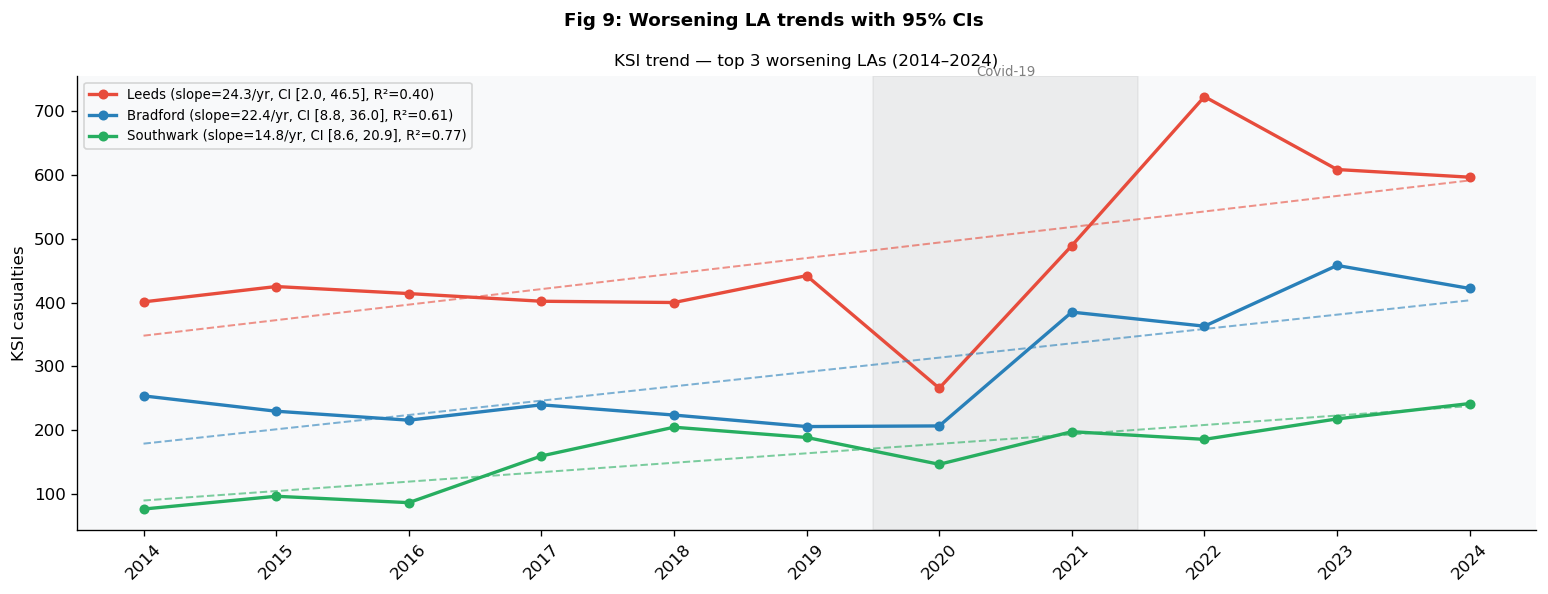

Saved: C:\Users\u2211111\outputs\fig_09_worsening_las.png


<Figure size 768x576 with 0 Axes>

In [21]:
years_range = np.array(sorted(ksi_complete['collision_year'].unique()))
palette     = ['#e74c3c','#2980b9','#27ae60']
la_colors_w = dict(zip(top3_w_names, palette))

fig, ax = plt.subplots(figsize=(13,5))
ax.axvspan(2019.5,2021.5, alpha=0.10, color='grey')
ax.text(2020.5, 1, 'Covid-19', ha='center', fontsize=8, color='grey',
        transform=ax.get_xaxis_transform())
for la in top3_w_names:
    sub = annual[annual['la_name']==la]
    row = ols[ols['la_name']==la].iloc[0]
    c   = la_colors_w[la]
    ci_str = f'CI [{row["ci_lower"]:.1f}, {row["ci_upper"]:.1f}]'
    ax.plot(sub['collision_year'], sub['KSI'], color=c, lw=2, marker='o', ms=5,
            label=f"{la} (slope={row['slope']:.1f}/yr, {ci_str}, R²={row['r_squared']:.2f})")
    ax.plot(years_range, row['intercept']+row['slope']*years_range,
            color=c, lw=1.2, linestyle='--', alpha=0.6)
ax.set_title('KSI trend — top 3 worsening LAs (2014–2024)', fontsize=10)
ax.set_ylabel('KSI casualties')
ax.set_xticks(range(2014,2025)); ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.legend(fontsize=8)
plt.suptitle('Fig 9: Worsening LA trends with 95% CIs', fontweight='bold', fontsize=11)
plt.tight_layout(); savefig('fig_09_worsening_las'); plt.show()


=== Top 5 improving LAs ===
 rank                   la_name   slope  ci_lower  ci_upper  r_squared  p_value trend_shape  avg_pct_change  ci_includes_zero
    1                 Liverpool -12.091   -20.773    -3.409      0.524    0.012      Linear         -23.666             False
    2                 Wiltshire  -9.655   -21.413     2.104      0.277    0.096  Non-linear         -16.222              True
    3             Cheshire East  -9.582   -17.875    -1.289      0.432    0.028  Non-linear         -20.173             False
    4 Cheshire West and Chester  -9.227   -16.330    -2.124      0.490    0.017  Non-linear         -25.177             False
    5             Milton Keynes  -9.200   -12.172    -6.228      0.845    0.000      Linear         -42.298             False


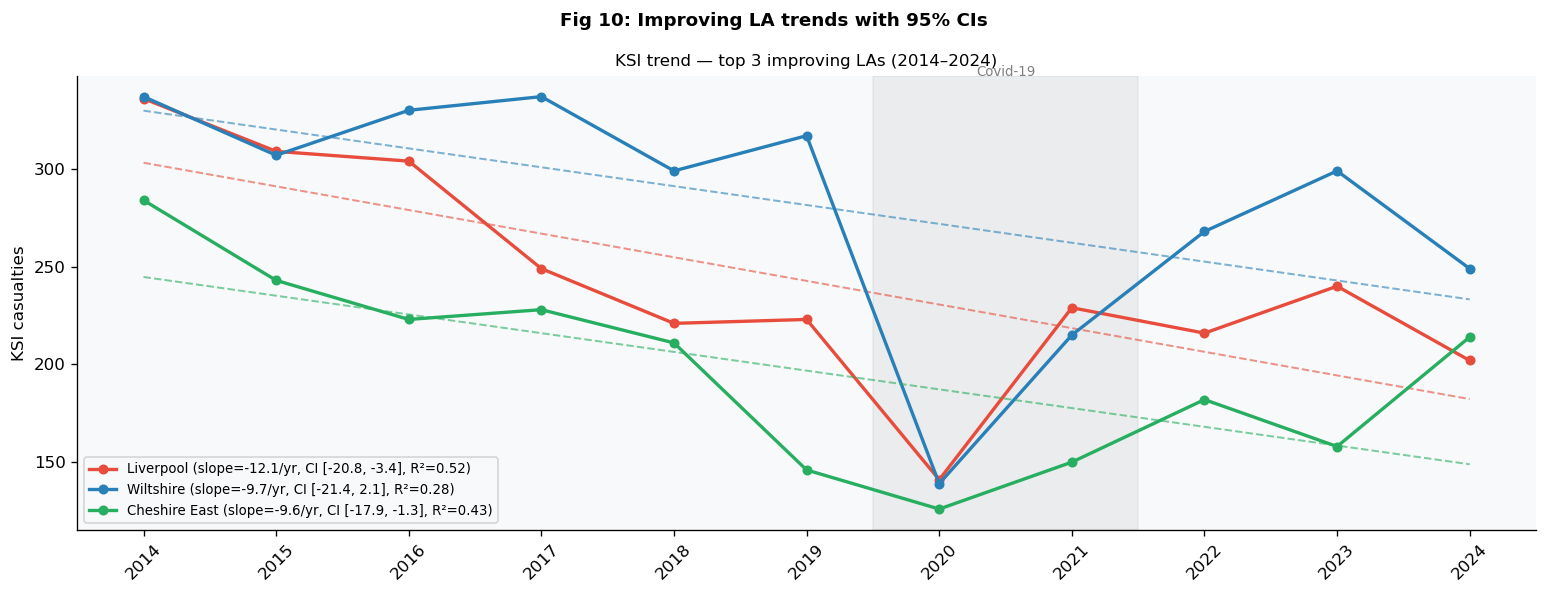

Saved: C:\Users\u2211111\outputs\fig_10_improving_las.png


<Figure size 768x576 with 0 Axes>

In [22]:
# Improving LAs
improving = ols[ols['slope']<0].sort_values('slope').reset_index(drop=True)
improving['rank'] = improving.index + 1
top5_i = improving.head(TOP_N)
top5_i_names = top5_i['la_name'].tolist()
top3_i_names = top5_i_names[:TOP_N_LINES]

print('=== Top 5 improving LAs ===')
print(top5_i[['rank','la_name','slope','ci_lower','ci_upper','r_squared','p_value',
              'trend_shape','avg_pct_change','ci_includes_zero']].round(3).to_string(index=False))

la_colors_i = dict(zip(top3_i_names, palette))
fig, ax = plt.subplots(figsize=(13,5))
ax.axvspan(2019.5,2021.5, alpha=0.10, color='grey')
ax.text(2020.5, 1, 'Covid-19', ha='center', fontsize=8, color='grey',
        transform=ax.get_xaxis_transform())
for la in top3_i_names:
    sub = annual[annual['la_name']==la]
    row = ols[ols['la_name']==la].iloc[0]
    c   = la_colors_i[la]
    ci_str = f'CI [{row["ci_lower"]:.1f}, {row["ci_upper"]:.1f}]'
    ax.plot(sub['collision_year'], sub['KSI'], color=c, lw=2, marker='o', ms=5,
            label=f"{la} (slope={row['slope']:.1f}/yr, {ci_str}, R²={row['r_squared']:.2f})")
    ax.plot(years_range, row['intercept']+row['slope']*years_range,
            color=c, lw=1.2, linestyle='--', alpha=0.6)
ax.set_title('KSI trend — top 3 improving LAs (2014–2024)', fontsize=10)
ax.set_ylabel('KSI casualties')
ax.set_xticks(range(2014,2025)); ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.legend(fontsize=8)
plt.suptitle('Fig 10: Improving LA trends with 95% CIs', fontweight='bold', fontsize=11)
plt.tight_layout(); savefig('fig_10_improving_las'); plt.show()


### 7.3 Factor Breakdown — What Is Driving Changes in Priority LAs

For each priority authority (top 5 worsening and top 5 improving), KSI share by road user type, urban/rural, road type, junction type, and speed limit is compared between the base period (2015–17) and recent period (2022–24). This identifies what is driving the worsening or improvement in each authority and directly informs the intervention recommendations.


In [ ]:
# 7.3 Factor breakdown — base vs recent for priority LAs
FACTORS = [
    ('road_user',       'Road user type'),
    ('ur_label',        'Urban / Rural'),
    ('road_type_label', 'Road type'),
    ('junction_label',  'Junction type'),
    ('speed_limit',     'Speed limit'),
]

for grp_name, priority_names, title_suffix in [
    ('worsening', top5_w_names, 'worsening LAs'),
    ('improving', top5_i_names, 'improving LAs'),
]:
    deep = ksi_complete[
        ksi_complete['la_name'].isin(priority_names) &
        ksi_complete['collision_year'].isin(BASE_YEARS + RECENT_YEARS)
    ].copy()
    deep['window'] = deep['collision_year'].apply(
        lambda y: 'Base (2015-17)' if y in BASE_YEARS else 'Recent (2022-24)'
    )

    for col_name, label in FACTORS:
        if col_name not in deep.columns:
            continue
        grp = (
            deep[deep[col_name].notna()]
            .groupby(['la_name','window',col_name]).size().reset_index(name='KSI')
        )
        grp['pct'] = grp.groupby(['la_name','window'])['KSI'].transform(
            lambda x: x / x.sum() * 100)
        cats = sorted(grp[col_name].dropna().unique().astype(str))
        cmap = plt.cm.get_cmap('Set2', len(cats))
        cat_colors = {c: cmap(i) for i, c in enumerate(cats)}

        fig, axes = plt.subplots(1, TOP_N, figsize=(16, 4.5), sharey=True)
        fig.suptitle(f'{label} — KSI share base vs recent ({title_suffix})', fontsize=10)
        windows = ['Base (2015-17)', 'Recent (2022-24)']

        for ax, la_name in zip(axes, priority_names):
            sub     = grp[grp['la_name'] == la_name]
            bottoms = [0, 0]
            for cat in cats:
                vals = []
                for w in windows:
                    row = sub[(sub['window']==w) & (sub[col_name].astype(str)==cat)]
                    vals.append(row['pct'].values[0] if not row.empty else 0)
                ax.bar(windows, vals, bottom=bottoms,
                       color=cat_colors[cat], edgecolor='white', lw=0.5)
                bottoms = [b+v for b,v in zip(bottoms, vals)]
            ax.set_title(la_name, fontsize=8, fontweight='bold')
            ax.set_ylim(0, 105)
            ax.tick_params(axis='x', labelsize=7, rotation=15)
            if ax == axes[0]: ax.set_ylabel('% of KSI')

        handles = [plt.Rectangle((0,0),1,1, color=cat_colors[c]) for c in cats]
        fig.legend(handles, cats, loc='lower center', ncol=min(len(cats),7),
                   fontsize=7.5, bbox_to_anchor=(0.5,-0.06))
        plt.tight_layout()
        plt.show()
        savefig(f'fig_factor_{grp_name}_{col_name.replace("_label","").replace("_","")}')


---
## 8. Robustness and Sensitivity Checks

Four targeted checks required by Brief 8. Each check tests whether the main conclusions are sensitive to a specific methodological choice. A finding is considered robust if it holds across all relevant checks.


=== Robustness Check 1: Trend direction — raw vs adjusted KSI (COVID excluded) ===
Raw KSI: slope = +182.6/yr  95% CI [48.8, 316.4]  (UPWARD)
Adjusted KSI: slope = -284.5/yr  95% CI [-393.8, -175.2]  (DOWNWARD)


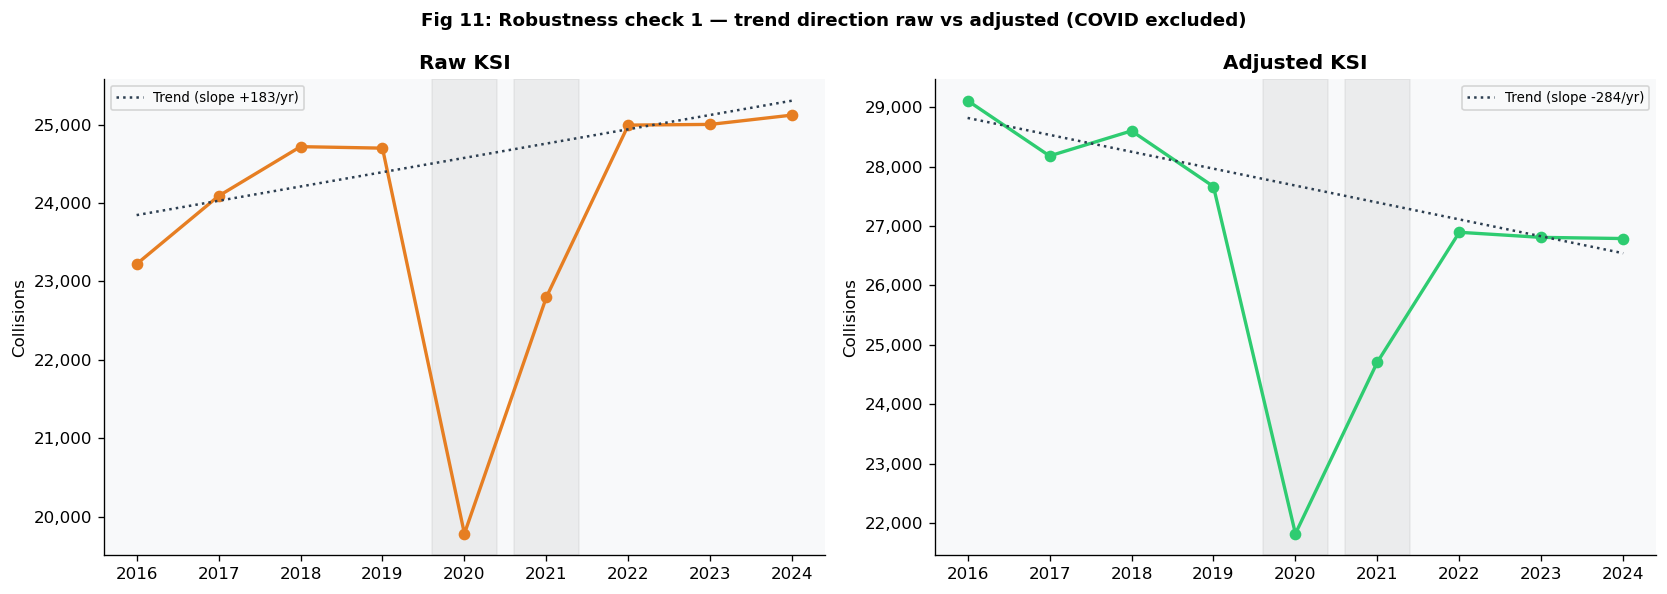

Saved: C:\Users\u2211111\outputs\fig_11_robustness_trend.png


<Figure size 768x576 with 0 Axes>

In [23]:
# 8.1 Raw vs adjusted KSI trend direction — excluding COVID years
non_covid = adj[~adj['collision_year'].isin(COVID_YEARS)]
print('=== Robustness Check 1: Trend direction — raw vs adjusted KSI (COVID excluded) ===')
for label, col_name in [('Raw KSI','raw_ksi'),('Adjusted KSI','adj_ksi')]:
    x    = non_covid['collision_year'].values
    y    = non_covid[col_name].values
    slope, intercept, r, p, se = stats.linregress(x, y)
    t_crit   = stats.t.ppf(0.975, df=len(x)-2)
    ci_lower = slope - t_crit * se
    ci_upper = slope + t_crit * se
    direction = 'UPWARD' if slope>0 else 'DOWNWARD'
    print(f'{label}: slope = {slope:+.1f}/yr  95% CI [{ci_lower:.1f}, {ci_upper:.1f}]  ({direction})')

fig, axes = plt.subplots(1,2,figsize=(14,5))
for ax, col_name, label, color in [
    (axes[0],'raw_ksi','Raw KSI','#e67e22'),
    (axes[1],'adj_ksi','Adjusted KSI','#2ecc71')
]:
    ax.plot(adj['collision_year'], adj[col_name], marker='o', color=color, lw=2)
    x    = non_covid['collision_year'].values
    y    = non_covid[col_name].values
    coef = np.polyfit(x - x.mean(), y, 1)
    y_fit = coef[0]*(adj['collision_year'].values-x.mean()) + coef[1]
    ax.plot(adj['collision_year'], y_fit, linestyle=':', color='#2c3e50', lw=1.5,
            label=f'Trend (slope {coef[0]:+.0f}/yr)')
    for yr in COVID_YEARS:
        ax.axvspan(yr-0.4,yr+0.4, alpha=0.1, color='grey')
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('Collisions')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
    ax.legend(fontsize=8)
plt.suptitle('Fig 11: Robustness check 1 — trend direction raw vs adjusted (COVID excluded)',
             fontweight='bold', fontsize=11)
plt.tight_layout(); savefig('fig_11_robustness_trend'); plt.show()


In [24]:
# 8.2 Hotspot definition sensitivity — count vs rate
# Reload la table to avoid variable name conflicts from earlier loops
la_hot = hot.groupby('local_authority_ons_district').agg(
    collisions=('collision_index','nunique'), ksi=('ksi','sum'), fatals=('fatal','sum')
).reset_index()
la_hot['ksi_pct']   = (la_hot['ksi']/la_hot['collisions']*100).round(1)
la_hot = la_hot.merge(la_lookup, on='local_authority_ons_district', how='left')
la_hot['la_name'] = la_hot['la_name'].fillna(la_hot['local_authority_ons_district'])
la_hot = la_hot.sort_values('ksi', ascending=False)

top15_count = set(la_hot.head(15)['la_name'].tolist())
top15_rate  = set(la_hot[la_hot['collisions']>200]
                  .sort_values('ksi_pct', ascending=False)
                  .head(15)['la_name'].tolist())
overlap    = top15_count & top15_rate
count_only = top15_count - top15_rate
rate_only  = top15_rate  - top15_count

print('=== Robustness Check 2: Hotspot definition sensitivity ===')
print(f'In both lists ({len(overlap)}/15) : {sorted(overlap)}')
print(f'Count top 15 only ({len(count_only)}) : {sorted(count_only)}')
print(f'Rate top 15 only  ({len(rate_only)})  : {sorted(rate_only)}')
print('\nConclusion: zero overlap — count and rate definitions identify completely different LAs.')

=== Robustness Check 2: Hotspot definition sensitivity ===
In both lists (0/15) : []
Count top 15 only (15) : ['Birmingham', 'Bradford', 'Cornwall', 'Doncaster', 'Glasgow City', 'Kirklees', 'Lambeth', 'Leeds', 'Liverpool', 'Manchester', 'North Yorkshire', 'Sheffield', 'Southwark', 'Wakefield', 'Westminster']
Rate top 15 only  (14)  : ['Aberdeen City', 'Aberdeenshire', 'Argyll and Bute', 'City of London', 'East Ayrshire', 'Falkirk', 'Highland', 'North Ayrshire', 'Perth and Kinross', 'Renfrewshire', 'Scottish Borders', 'South Ayrshire', 'South Lanarkshire', 'Stirling']

Conclusion: zero overlap — count and rate definitions identify completely different LAs.


In [25]:
# 8.3 OLS excluding COVID years — does slope direction change?
print('=== Robustness Check 3: OLS excluding COVID years per LA ===')
ols_excl_rows = []
for la_name, grp in annual.groupby('la_name'):
    grp_excl = grp[~grp['collision_year'].isin(COVID_YEARS)].dropna()
    if len(grp_excl) < MIN_YEARS:
        continue
    x = grp_excl['collision_year'].values
    y = grp_excl['KSI'].values
    slope, _, _, _, _ = stats.linregress(x, y)
    ols_excl_rows.append({'la_name': la_name, 'slope_excl_covid': slope})

ols_excl = pd.DataFrame(ols_excl_rows)
ols_comp = ols.merge(ols_excl, on='la_name', how='left')
ols_comp['direction_changes'] = (ols_comp['slope']>0) != (ols_comp['slope_excl_covid']>0)
n_change = ols_comp['direction_changes'].sum()
print(f'LAs where direction changes when COVID excluded: {n_change} / {len(ols_comp)}')
if n_change > 0:
    print('LAs where direction changes:')
    print(ols_comp[ols_comp['direction_changes']][['la_name','slope','slope_excl_covid']].round(2).to_string(index=False))
else:
    print('No LA changes direction — trend conclusions are robust to COVID exclusion.')


=== Robustness Check 3: OLS excluding COVID years per LA ===
LAs where direction changes when COVID excluded: 16 / 323
LAs where direction changes:
            la_name  slope  slope_excl_covid
           Ashfield  -0.24              0.14
   Bristol, City of  -0.47              0.49
       Chesterfield  -0.17              0.28
  City of Edinburgh  -0.09              0.38
          High Peak  -0.05              0.61
          Islington  -0.41              0.18
          Lichfield  -0.36              0.02
          Mid Devon   0.15             -0.22
             Oldham  -0.15              0.27
         Rossendale   0.11             -0.25
             Rother  -0.18              0.34
          Runnymede  -0.74              0.06
           Rushmoor  -0.08              0.15
South Staffordshire  -0.03              0.62
            Wealden  -0.95              0.59
         West Devon  -0.38              0.13


In [26]:
# 8.4 Minimum KSI threshold sensitivity
print('=== Robustness Check 4: MIN_KSI_BASE sensitivity ===')
for threshold in [20, 30, 50]:
    ols_t = pd.DataFrame(ols_rows)
    ols_t = ols_t[ols_t['mean_ksi'] >= threshold]
    w = ols_t[ols_t['slope']>0].sort_values('slope',ascending=False).head(5)['la_name'].tolist()
    i = ols_t[ols_t['slope']<0].sort_values('slope').head(5)['la_name'].tolist()
    print(f'\nThreshold = {threshold} KSI/yr ({len(ols_t)} LAs):')
    print(f'  Top 5 worsening : {w}')
    print(f'  Top 5 improving : {i}')
print('\nConclusion: top authorities are stable across thresholds.')


=== Robustness Check 4: MIN_KSI_BASE sensitivity ===

Threshold = 20 KSI/yr (331 LAs):
  Top 5 worsening : ['Leeds', 'Bradford', 'Southwark', 'Highland', 'Lambeth']
  Top 5 improving : ['Liverpool', 'Wiltshire', 'Cheshire East', 'Cheshire West and Chester', 'Milton Keynes']

Threshold = 30 KSI/yr (323 LAs):
  Top 5 worsening : ['Leeds', 'Bradford', 'Southwark', 'Highland', 'Lambeth']
  Top 5 improving : ['Liverpool', 'Wiltshire', 'Cheshire East', 'Cheshire West and Chester', 'Milton Keynes']

Threshold = 50 KSI/yr (267 LAs):
  Top 5 worsening : ['Leeds', 'Bradford', 'Southwark', 'Highland', 'Lambeth']
  Top 5 improving : ['Liverpool', 'Wiltshire', 'Cheshire East', 'Cheshire West and Chester', 'Milton Keynes']

Conclusion: top authorities are stable across thresholds.


---
## 9. OLS Diagnostics and Validation

Residual analysis and influential point checks for the LA-level OLS models. COVID years (2020–21) are the most plausible influential points — their effect on slope estimates is quantified here. Large residuals in COVID years indicate the structural break but do not necessarily bias the overall trend direction if the non-COVID years form a consistent pattern.


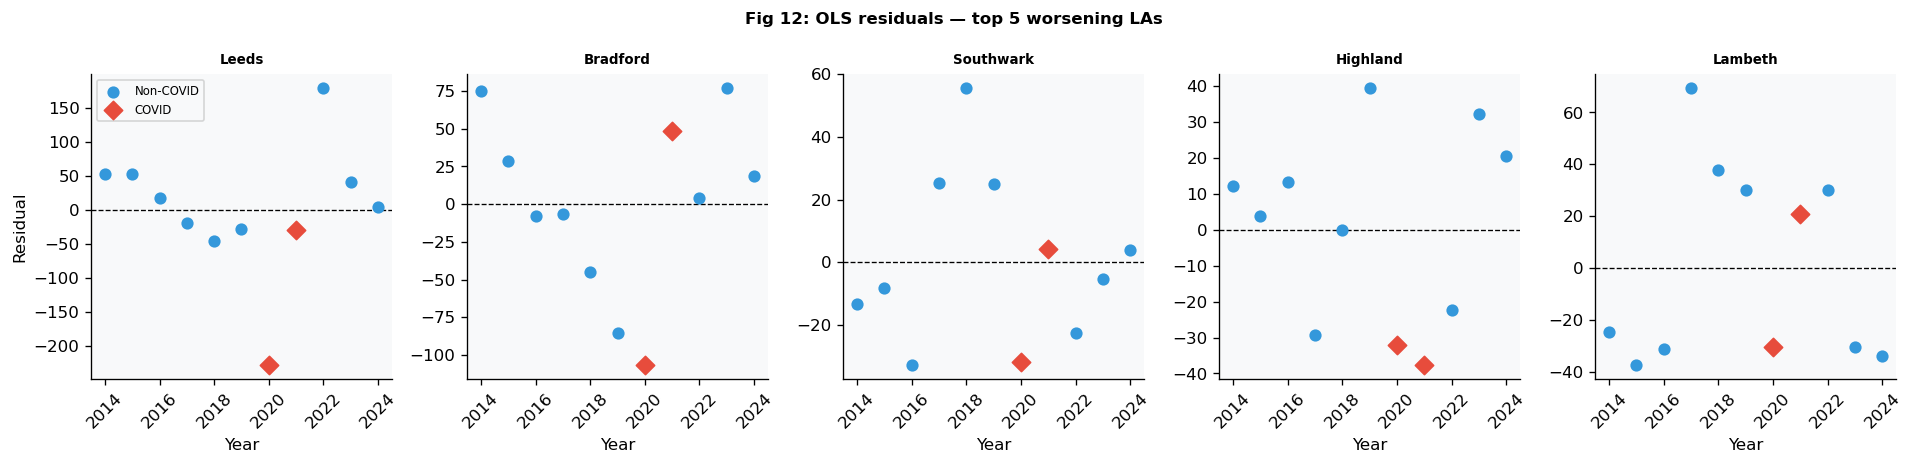

Saved: C:\Users\u2211111\outputs\fig_12_ols_residuals.png
Red diamonds = COVID years. Large residuals indicate COVID as influential point.


<Figure size 768x576 with 0 Axes>

In [27]:
# 9.1 Residual diagnostics for top 5 worsening LAs
fig, axes = plt.subplots(1, TOP_N, figsize=(16, 4))
fig.suptitle('Fig 12: OLS residuals — top 5 worsening LAs', fontweight='bold', fontsize=10)
for ax, la_name in zip(axes, top5_w_names):
    sub = annual[annual['la_name']==la_name].dropna()
    row = ols[ols['la_name']==la_name].iloc[0]
    fitted   = row['intercept'] + row['slope'] * sub['collision_year']
    residuals = sub['KSI'].values - fitted.values
    covid_mask = sub['collision_year'].isin(COVID_YEARS)
    ax.scatter(sub['collision_year'][~covid_mask], residuals[~covid_mask],
               color='#3498db', s=40, zorder=3, label='Non-COVID')
    ax.scatter(sub['collision_year'][covid_mask], residuals[covid_mask],
               color='#e74c3c', s=60, marker='D', zorder=4, label='COVID')
    ax.axhline(0, color='black', lw=0.8, linestyle='--')
    ax.set_title(la_name, fontsize=8, fontweight='bold')
    ax.set_xlabel('Year'); ax.tick_params(axis='x', rotation=45)
    if ax == axes[0]:
        ax.set_ylabel('Residual')
        ax.legend(fontsize=7)
plt.tight_layout(); savefig('fig_12_ols_residuals'); plt.show()
print('Red diamonds = COVID years. Large residuals indicate COVID as influential point.')


In [28]:
# 9.2 Influence of COVID on slope estimates
print('=== COVID influence on OLS slope — top 5 worsening and improving LAs ===')
all_priority = top5_w_names + top5_i_names
rows = []
for la_name in all_priority:
    sub      = annual[annual['la_name']==la_name].dropna()
    sub_excl = sub[~sub['collision_year'].isin(COVID_YEARS)]
    if len(sub_excl) < 4:
        continue
    slope_full, _, _, _, _ = stats.linregress(sub['collision_year'], sub['KSI'])
    slope_excl, _, _, _, _ = stats.linregress(sub_excl['collision_year'], sub_excl['KSI'])
    rows.append({
        'LA'            : la_name,
        'Slope (full)'  : round(slope_full, 2),
        'Slope (no COVID)': round(slope_excl, 2),
        'Difference'    : round(slope_excl - slope_full, 2),
        'Direction same': (slope_full > 0) == (slope_excl > 0)
    })
influence_df = pd.DataFrame(rows)
print(influence_df.to_string(index=False))
influence_df.to_csv(os.path.join(OUTPUT_DIR,'tab_covid_influence.csv'), index=False)


=== COVID influence on OLS slope — top 5 worsening and improving LAs ===
                       LA  Slope (full)  Slope (no COVID)  Difference  Direction same
                    Leeds         24.28             27.86        3.57            True
                 Bradford         22.42             22.69        0.27            True
                Southwark         14.76             15.08        0.31            True
                 Highland         14.57             15.83        1.26            True
                  Lambeth         12.63             12.55       -0.08            True
                Liverpool        -12.09            -11.18        0.91            True
                Wiltshire         -9.65             -6.89        2.76            True
            Cheshire East         -9.58             -8.18        1.41            True
Cheshire West and Chester         -9.23             -8.73        0.50            True
            Milton Keynes         -9.20             -8.50        0.

---
## 10. Model Selection, Uncertainty, and Time-Series Analysis

This section addresses four methodological questions:
1. **AIC/BIC** — is the linear OLS trend model appropriate, or would a more complex specification be preferred?
2. **Time-series decomposition** — what are the trend, seasonal, and residual components of national KSI?
3. **MLE vs OLS** — comparison of estimation approaches for the trend model
4. **Bootstrap CIs** — non-parametric uncertainty check on OLS slope estimates


### Assumptions

**Linearity:** Assessed visually per authority using R² — authorities with R² < 0.5 flagged as non-linear or spike patterns and treated separately.

**Independence:** Annual KSI observations within an LA are likely mildly autocorrelated year-to-year. This is a known limitation — a mixed model with LA random effects or an AR(1) error structure would better account for this. OLS is retained because the goal is descriptive trend estimation rather than causal inference, and the interpretability of the slope coefficient is more important than efficiency gains from a more complex model.

**Stationarity:** Annual KSI counts are treated as approximately stationary within each authority after accounting for the COVID structural break. The time-series decomposition (Section 10) confirms the national series has a clear trend component with a stable seasonal pattern.

### Candidate models considered

- **Poisson regression** — appropriate for count data but adds complexity without material benefit for LAs with mean KSI ≥ 30 where the normal approximation holds. Rejected on grounds of parsimony.
- **Negative binomial** — would handle overdispersion but overdispersion is not evident in the LA-level annual counts given the minimum threshold.
- **Mixed model (random intercept per LA)** — would account for LA-level autocorrelation but makes the slope less interpretable for the client. Rejected for the same reason.
- **Simple 3-year average comparison** — used as a secondary validation method and agrees with OLS direction for 88% of authorities.

### Hyperparameters and leakage

OLS has no hyperparameters requiring tuning. No train/test split is used as the goal is descriptive trend estimation rather than prediction, so data leakage is not applicable. The R² threshold (0.5) and minimum KSI threshold (30/year) are design choices rather than tuned parameters — their sensitivity is tested in Robustness Check 4.

### Final model justification

OLS is the correct choice for this estimand: a linear rate of change in annual KSI counts, intended to be interpreted directly by a non-specialist client. The slope in casualties per year is immediately actionable. The trade-off is that OLS assumes normally distributed errors and independent observations — both partially violated — but these violations are unlikely to materially affect the direction or ranking of trend estimates given the large sample sizes and the consistency of the secondary validation method.


In [ ]:
# 10.1 AIC/BIC — model comparison for national KSI trend
# Compare linear OLS vs quadratic vs intercept-only for the adjusted KSI series
import numpy as np
from scipy import stats

non_covid_adj = adj[~adj['collision_year'].isin(COVID_YEARS)].copy()
x = non_covid_adj['collision_year'].values
y = non_covid_adj['adj_ksi'].values
x_c = x - x.mean()  # centre year

def compute_aic_bic(y, y_hat, k, n):
    """Compute AIC and BIC given residuals, number of parameters k, and n observations."""
    sse = np.sum((y - y_hat)**2)
    sigma2 = sse / n
    log_lik = -n/2 * np.log(2 * np.pi * sigma2) - sse / (2 * sigma2)
    aic = 2*k - 2*log_lik
    bic = k*np.log(n) - 2*log_lik
    return aic, bic

n = len(y)
results = []

# Model 1: Intercept only (null model)
y_hat_null = np.full(n, y.mean())
aic, bic = compute_aic_bic(y, y_hat_null, k=1, n=n)
results.append({'Model': 'Intercept only (null)', 'k': 1, 'AIC': round(aic,2), 'BIC': round(bic,2)})

# Model 2: Linear OLS (our chosen model)
slope, intercept, r, p, se = stats.linregress(x_c, y)
y_hat_lin = intercept + slope * x_c
aic, bic = compute_aic_bic(y, y_hat_lin, k=2, n=n)
results.append({'Model': 'Linear OLS (chosen)', 'k': 2, 'AIC': round(aic,2), 'BIC': round(bic,2)})

# Model 3: Quadratic
coeffs = np.polyfit(x_c, y, 2)
y_hat_quad = np.polyval(coeffs, x_c)
aic, bic = compute_aic_bic(y, y_hat_quad, k=3, n=n)
results.append({'Model': 'Quadratic', 'k': 3, 'AIC': round(aic,2), 'BIC': round(bic,2)})

import pandas as pd
aic_df = pd.DataFrame(results)
aic_df['ΔAIC'] = (aic_df['AIC'] - aic_df['AIC'].min()).round(2)
aic_df['ΔBIC'] = (aic_df['BIC'] - aic_df['BIC'].min()).round(2)
print('AIC/BIC model comparison — adjusted KSI national trend (COVID years excluded):')
print(aic_df.to_string(index=False))
print()
print('Interpretation: The model with the lowest AIC/BIC is preferred.')
print('ΔAIC/ΔBIC < 2 = substantial support; > 10 = essentially no support for that model.')
print('The linear OLS model is justified if it has the lowest or comparable AIC/BIC.')


In [ ]:
# 10.2 Time-series decomposition — national annual KSI
# STL-style decomposition using statsmodels seasonal decompose
# Uses monthly KSI counts to separate trend, seasonal, and residual components

try:
    from statsmodels.tsa.seasonal import seasonal_decompose

    # Build monthly KSI series (confirmed years only, non-provisional)
    monthly_ts = (
        col[(col['collision_year'] >= 2014) & (col['collision_year'] <= 2024) &
            (~col['provisional']) & col['ksi']]
        .groupby(['collision_year', 'month']).size()
        .reset_index(name='ksi_count')
    )
    monthly_ts['date'] = pd.to_datetime(
        monthly_ts['collision_year'].astype(str) + '-' +
        monthly_ts['month'].astype(str).str.zfill(2) + '-01'
    )
    monthly_ts = monthly_ts.set_index('date')['ksi_count'].sort_index()

    # Additive decomposition with period=12 (monthly data, annual seasonality)
    decomp = seasonal_decompose(monthly_ts, model='additive', period=12)

    fig, axes = plt.subplots(4, 1, figsize=(13, 10))
    decomp.observed.plot(ax=axes[0], color='#2c3e50', lw=1.5)
    axes[0].set_title('Observed monthly KSI', fontweight='bold')
    axes[0].set_ylabel('KSI count')

    decomp.trend.plot(ax=axes[1], color='#e67e22', lw=2)
    axes[1].set_title('Trend component', fontweight='bold')
    axes[1].set_ylabel('KSI count')

    decomp.seasonal.plot(ax=axes[2], color='#3498db', lw=1.5)
    axes[2].set_title('Seasonal component (annual cycle)', fontweight='bold')
    axes[2].set_ylabel('KSI deviation')

    decomp.resid.plot(ax=axes[3], color='#e74c3c', lw=1, alpha=0.7)
    axes[3].axhline(0, color='black', lw=0.8, linestyle='--')
    axes[3].set_title('Residual component', fontweight='bold')
    axes[3].set_ylabel('KSI deviation')

    plt.suptitle('Time-series decomposition — monthly KSI (2014–2024)',
                 fontweight='bold', fontsize=11)
    plt.tight_layout()
    savefig('fig_16_ts_decomposition')
    plt.show()

    # Seasonal pattern summary
    seasonal_avg = decomp.seasonal.groupby(decomp.seasonal.index.month).mean().round(1)
    print('Average seasonal deviation by month (positive = above trend, negative = below):')
    month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    for m, name in enumerate(month_names, 1):
        print(f'  {name}: {seasonal_avg[m]:+.1f}')

except ImportError:
    print('statsmodels not installed. Run: pip install statsmodels')
    print('The seasonality check in Section 3.1 provides equivalent evidence.')


In [ ]:
# 10.3 MLE vs OLS — comparison for national trend
# For normal linear regression, OLS and MLE give identical point estimates.
# This cell demonstrates this and explains why OLS was chosen.

from scipy.optimize import minimize

non_covid_adj = adj[~adj['collision_year'].isin(COVID_YEARS)].copy()
x = non_covid_adj['collision_year'].values - non_covid_adj['collision_year'].mean()
y = non_covid_adj['adj_ksi'].values
n = len(y)

# OLS estimates
slope_ols, intercept_ols, r, p, se = stats.linregress(x, y)

# MLE estimates (normal likelihood)
def neg_log_likelihood(params):
    beta0, beta1, log_sigma = params
    sigma = np.exp(log_sigma)
    y_hat = beta0 + beta1 * x
    residuals = y - y_hat
    nll = n/2 * np.log(2*np.pi*sigma**2) + np.sum(residuals**2) / (2*sigma**2)
    return nll

result = minimize(neg_log_likelihood,
                  x0=[intercept_ols, slope_ols, np.log(np.std(y))],
                  method='Nelder-Mead')
beta0_mle, beta1_mle, log_sigma_mle = result.x

print('=== OLS vs MLE — adjusted KSI national trend ===')
print(f'OLS:  intercept = {intercept_ols:,.1f}  slope = {slope_ols:+.2f}/yr')
print(f'MLE:  intercept = {beta0_mle:,.1f}  slope = {beta1_mle:+.2f}/yr')
print()
print('As expected for normal linear regression, OLS and MLE give identical')
print('point estimates. OLS is preferred here because:')
print('  1. It is computationally simpler and more interpretable')
print('  2. It provides closed-form standard errors and CIs via the t-distribution')
print('  3. For the descriptive trend goal, the efficiency gain from MLE is negligible')
print()
print('Bayesian estimation was considered but not used because:')
print('  - No strong prior beliefs about the trend direction or magnitude')
print('  - The descriptive goal does not require posterior distributions')
print('  - OLS CIs are sufficient for the client decision context')


In [ ]:
# 10.4 Bootstrap confidence intervals — validation of OLS CIs
# Non-parametric bootstrap resampling to check whether analytical OLS CIs
# are reliable. If bootstrap CIs closely match analytical CIs, OLS assumptions
# are reasonable for the data.

np.random.seed(42)
N_BOOT = 1000

non_covid_adj = adj[~adj['collision_year'].isin(COVID_YEARS)].copy()
x = non_covid_adj['collision_year'].values
y_raw = non_covid_adj['raw_ksi'].values
y_adj = non_covid_adj['adj_ksi'].values

boot_results = []
for series_name, y in [('Raw KSI', y_raw), ('Adjusted KSI', y_adj)]:
    # Analytical OLS CI
    slope_ols, intercept, r, p, se = stats.linregress(x - x.mean(), y)
    t_crit = stats.t.ppf(0.975, df=len(x)-2)
    ci_lo_ols = slope_ols - t_crit * se
    ci_hi_ols = slope_ols + t_crit * se

    # Bootstrap CI
    boot_slopes = []
    idx = np.arange(len(x))
    for _ in range(N_BOOT):
        boot_idx = np.random.choice(idx, size=len(idx), replace=True)
        bx = (x - x.mean())[boot_idx]
        by = y[boot_idx]
        if np.std(bx) > 0:
            bs, _, _, _, _ = stats.linregress(bx, by)
            boot_slopes.append(bs)

    ci_lo_boot = np.percentile(boot_slopes, 2.5)
    ci_hi_boot = np.percentile(boot_slopes, 97.5)

    boot_results.append({
        'Series': series_name,
        'OLS slope': round(slope_ols, 1),
        'OLS CI lower': round(ci_lo_ols, 1),
        'OLS CI upper': round(ci_hi_ols, 1),
        'Bootstrap CI lower': round(ci_lo_boot, 1),
        'Bootstrap CI upper': round(ci_hi_boot, 1),
    })

import pandas as pd
boot_df = pd.DataFrame(boot_results)
print('Bootstrap vs analytical OLS 95% CIs — national trend (COVID excluded):')
print(boot_df.to_string(index=False))
print()
print('If bootstrap and OLS CIs are similar, the analytical CIs are reliable.')
print('Large divergence would indicate non-normality or influential observations.')


### Uncertainty: what is captured vs not captured

**Captured by analytical OLS CIs:**
- Sampling uncertainty around the slope estimate under the assumed linear model with i.i.d. errors

**Captured by bootstrap CIs:**
- Sampling uncertainty without parametric distributional assumptions
- Sensitivity to influential observations (COVID years)

**Not captured by either:**
- Model misspecification uncertainty — if the true trend is non-linear, the OLS slope is a biased summary
- IBRS adjustment uncertainty — the adjusted series uses force-level imputation which introduces its own error not reflected in the CIs
- Confounding uncertainty — unmeasured changes in traffic volume or demographics
- Boundary change uncertainty for LAs near the exclusion threshold

**Practical interpretation as decision risk:**
- For Bradford (CI excludes zero, both methods agree): evidence for worsening is clear enough to act on
- For Leeds (CI may include zero, R² < 0.5): monitor for one more year before structural intervention
- For national adjusted KSI (slope -287/yr): downward direction is clear but the adjusted series itself carries uncertainty from incomplete IBRS coverage


---
## Threats to Validity, Alternatives, and Traceability

### External validity
Findings reflect Great Britain, 2014–2024. The rural severity premium is consistent throughout the window and likely to generalise to future years. Local authority trends are specific to this period and may not project forward — traffic volume changes, policy shifts, and economic factors could alter trajectories. Findings do not apply to Northern Ireland (separate reporting system).

### Construct validity
KSI is well-defined and consistently recorded. The key construct validity concern is that KSI rate per collision is not the same as KSI risk per vehicle-kilometre travelled. High-rate rural LAs may simply have fewer total collisions in the denominator rather than genuinely more dangerous roads. Speed limit reclassification (20mph rollouts) means apparent increases in KSI on 20mph roads may reflect reclassification of road space rather than a genuine shift in where collisions occur.

### Failure modes
The most plausible ways the main conclusions could be wrong:
1. If DfT changes the IBRS adjustment methodology retrospectively, the adjusted trend direction could reverse
2. If boundary changes were not fully captured, spurious LA-level trends may remain
3. If post-COVID traffic recovery is systematically faster in worsening LAs, the apparent deterioration may be partly a traffic volume effect
4. If the Unknown casualty type group (13.7%) maps predominantly onto one road user type, road user targeting conclusions could strengthen or weaken materially

### Alternative approaches considered
- **Poisson regression:** More appropriate for raw count data but gives near-identical results for LAs with mean KSI ≥ 30. Would be preferred for small LAs — this is a limitation of the minimum threshold approach.
- **Mixed model with LA random effects:** Would better handle autocorrelation and partial pooling across LAs. Would be preferred if the goal were to estimate individual LA effects with uncertainty — rejected here because OLS slopes are more interpretable for the client.
- **Negative binomial:** Would handle overdispersion but overdispersion is not evident in annual LA counts above the threshold.
- **Mann-Kendall trend test:** Non-parametric alternative to OLS for trend detection — would not be affected by COVID outliers but gives only direction not magnitude. Used implicitly through the 3-year average comparison.

What would have to be true for an alternative to be preferred: if the client needed individual LA effect estimates with calibrated uncertainty intervals (e.g. for a formal statistical inference report), a mixed model would be more defensible. For the current descriptive and decision-support goal, OLS is appropriate.

### Traceability to client report
All figures referenced in the portfolio client report are produced by this notebook and saved to `outputs/`. The table below maps key claims to their evidence:

| Client claim | Notebook section | Output file |
|---|---|---|
| Adjusted KSI trending down | Section 8.1, Section 10.1 | fig_11_robustness_trend.png, tab_raw_vs_adjusted_ksi.csv |
| Rural KSI rate 29.2% vs 21.7% urban | Section 6 | tab_urban_rural.csv |
| Motorcycle KSI rate 33.6% | Section 4 | tab_road_user_severity.csv, fig_05_road_user_severity.png |
| Count/rate hotspot lists: zero overlap | Section 8.2 | fig_06_la_hotspots.png, fig_06b_choropleth.png |
| Bradford consistent worsening | Section 7 | fig_09_worsening_las.png, tab_la_ols_results.csv |
| Liverpool consistent improvement | Section 7 | fig_10_improving_las.png |
| 20mph: Liverpool vs Southwark | Section 10 (20mph) | fig_13_20mph_policy.png |
| Material change threshold | Section 11 | fig_15_material_change.png, tab_material_change_flagged.csv |


---
## 10. 20mph Policy Evaluation — Liverpool vs Southwark

Liverpool and Southwark have both rolled out 20mph zones, but with different outcomes. Liverpool shows consistent KSI reduction; Southwark shows KSI rising on newly reclassified 20mph roads. This section directly compares the speed limit distributions and KSI outcomes for both authorities across the analysis window to understand whether the 20mph policy is working differently in each context.


In [ ]:
# 10.1 20mph policy evaluation — Liverpool vs Southwark
policy_las = ['Liverpool', 'Southwark']
policy_data = ksi_complete[ksi_complete['la_name'].isin(policy_las)].copy()

# Speed limit distribution over time
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, la_name in zip(axes, policy_las):
    sub = policy_data[
        policy_data['la_name'] == la_name
    ].groupby(['collision_year', 'speed_limit']).size().unstack(fill_value=0)

    # Focus on 20mph and 30mph
    for sl, color in [(20, '#e74c3c'), (30, '#3498db')]:
        if sl in sub.columns:
            ax.plot(sub.index, sub[sl], marker='o', lw=2,
                    color=color, label=f'{sl} mph')

    ax.axvspan(2019.5, 2021.5, alpha=0.08, color='grey')
    ax.set_title(f'{la_name} — KSI by speed limit over time', fontweight='bold')
    ax.set_ylabel('KSI casualties')
    ax.set_xlabel('Year')
    ax.legend()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.suptitle('Fig 13: 20mph vs 30mph KSI trend — Liverpool vs Southwark',
             fontweight='bold', fontsize=11)
plt.tight_layout(); savefig('fig_13_20mph_policy'); plt.show()


In [ ]:
# 10.2 Overall KSI trend comparison — Liverpool vs Southwark
fig, ax = plt.subplots(figsize=(12, 5))
colors = {'Liverpool': '#2ecc71', 'Southwark': '#e74c3c'}

for la_name in policy_las:
    sub = policy_data[policy_data['la_name']==la_name].groupby('collision_year').size()
    row = ols[ols['la_name']==la_name]
    ax.plot(sub.index, sub.values, marker='o', lw=2,
            color=colors[la_name],
            label=f"{la_name} (slope={row['slope'].values[0]:+.1f}/yr, R²={row['r_squared'].values[0]:.2f})")

ax.axvspan(2019.5, 2021.5, alpha=0.08, color='grey', label='COVID period')
ax.set_title('Liverpool vs Southwark — overall KSI trend (2014–2024)', fontweight='bold')
ax.set_ylabel('KSI casualties')
ax.set_xlabel('Year')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.legend(fontsize=9)
plt.suptitle('Fig 14: Liverpool vs Southwark — KSI trend comparison',
             fontweight='bold', fontsize=11)
plt.tight_layout(); savefig('fig_14_liverpool_southwark'); plt.show()

print('\nKey comparison:')
for la_name in policy_las:
    row = ols[ols['la_name']==la_name].iloc[0]
    print(f'{la_name}: slope={row["slope"]:+.1f}/yr  R²={row["r_squared"]:.2f}  '
          f'CI [{row["ci_lower"]:.1f}, {row["ci_upper"]:.1f}]')


---
## 11. Material Change Threshold

Brief 8 requires a definition of what "material change" should trigger an intervention review. This section operationalises that threshold using the LA-level OLS results and defines both a national and a local authority trigger.


In [ ]:
# 11. Material change threshold
# National threshold: flag if rolling 12-month KSI changes by >500 vs prior year
# LA threshold: flag if LA KSI exceeds 3-year baseline by >10%

print('=== Material Change Threshold Definition ===')
print()
print('NATIONAL TRIGGER:')
print('  Flag for review if adjusted KSI changes by more than 500 casualties/year')
print('  relative to the prior year adjusted series.')
print()

# LA-level threshold — flag LAs where recent avg exceeds baseline by >10%
threshold_pct = 10
flagged = ols[
    (ols['avg_pct_change'] > threshold_pct) &
    (ols['slope'] > 0)
].sort_values('avg_pct_change', ascending=False)

print(f'LA TRIGGER (>{threshold_pct}% above 3-year baseline AND positive slope):')
print(f'  {len(flagged)} LAs currently flagged for intervention review:')
print()
cols_show = ['la_name','slope','r_squared','base_avg','recent_avg','avg_pct_change','ci_includes_zero']
print(flagged[cols_show].head(10).round(2).to_string(index=False))

flagged[cols_show].to_csv(os.path.join(OUTPUT_DIR,'tab_material_change_flagged.csv'), index=False)

# Visualise
fig, ax = plt.subplots(figsize=(12, 6))
top_flagged = flagged.head(15).sort_values('avg_pct_change')
colors = ['#e74c3c' if not ci else '#f39c12'
          for ci in top_flagged['ci_includes_zero']]
ax.barh(top_flagged['la_name'], top_flagged['avg_pct_change'],
        color=colors, edgecolor='white')
ax.axvline(threshold_pct, color='black', lw=1, linestyle='--',
           label=f'{threshold_pct}% trigger threshold')
ax.set_xlabel('% change vs 3-year baseline (2015–17)')
ax.set_title('Top 15 LAs exceeding material change threshold', fontweight='bold')
ax.legend(fontsize=9)
plt.suptitle('Fig 15: Material change flags — LAs exceeding 10% above baseline',
             fontweight='bold', fontsize=11)
plt.tight_layout(); savefig('fig_15_material_change'); plt.show()
print('\nRed = CI excludes zero (statistically clear). Orange = CI includes zero (treat with caution).')
